<a href="https://colab.research.google.com/github/JuanCarlosAL91/deep-learning-2-TdeA/blob/main/Guia_10_Embeddings_Word2Vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AVISO LEGAL — PROPIEDAD INTELECTUAL

Este material es propiedad intelectual exclusiva de Julián David Flórez Sánchez (LinkedIn). Todos los derechos reservados. Queda terminantemente prohibida su copia, reproducción, distribución, adaptación o uso por cualquier persona natural o jurídica, pública o privada, sin autorización expresa y escrita del autor. El incumplimiento de esta disposición acarrea las sanciones civiles y penales previstas en la Ley 23 de 1982, la Decisión Andina 351 de 1993, los artículos 270-272 del Código Penal Colombiano y los tratados internacionales de propiedad intelectual aplicables. Para solicitar autorización: linkedin.com/in/julianflorezdata

# Guia 10: Word Embeddings y Word2Vec

## Electiva II - Deep Learning | Tecnologico de Antioquia

---

### Objetivo de aprendizaje

Comprender y aplicar **representaciones vectoriales densas de palabras** (word embeddings) que capturan significado semantico, superando las limitaciones de las representaciones dispersas (BoW/TF-IDF) estudiadas en la Guia 09.

### Conceptos nuevos en esta guia

| Concepto | Descripcion |
|----------|-------------|
| **Word Embeddings** | Representaciones vectoriales densas de palabras en un espacio continuo |
| **Representaciones densas vs dispersas** | Vectores compactos (50-300 dims) vs vectores enormes y llenos de ceros |
| **Word2Vec (CBOW y Skip-gram)** | Algoritmo que aprende embeddings a partir del contexto de las palabras |
| **Entrenamiento de embeddings propios** | Entrenar vectores con nuestro propio corpus usando Gensim |
| **Embeddings pre-entrenados** | Vectores entrenados en corpus masivos que podemos descargar y reutilizar |
| **fastText en espanol** | Extension de Word2Vec que usa subpalabras, ideal para idiomas con conjugaciones |
| **Visualizacion con t-SNE** | Reduccion de dimensionalidad para visualizar embeddings en 2D |
| **nn.Embedding en PyTorch** | Capa de embedding como primera capa de una red neuronal |

### Prerrequisito
- **Guia 09:** PLN Fundamentos con NLTK (tokenizacion, stemming, lematizacion, BoW, TF-IDF)

### Duracion estimada: 3 horas

### Entorno recomendado: Google Colab con GPU

> **Nota:** Selecciona `Entorno de ejecucion > Cambiar tipo de entorno de ejecucion > GPU T4` en Colab.

---

> **Aviso de evaluacion** ✍️: Las preguntas marcadas con ✍️ deben responderse de forma individual. Estas respuestas seran parte de la evaluacion del micro. Responde con tus propias palabras, demostrando comprension profunda de los conceptos.

---

## 1. Configuracion del Entorno

Instalamos las librerias necesarias. **Gensim** es la libreria principal para entrenar y usar Word2Vec.

In [1]:
# Instalacion de librerias necesarias
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.8 MB/s eta 0:00:00


In [2]:
# Importaciones principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter
import re
import time
import warnings
warnings.filterwarnings('ignore')

# Gensim para Word2Vec
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
import gensim.downloader as api

# NLTK para tokenizacion
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Scikit-learn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

print("Todas las librerias importadas correctamente.")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Todas las librerias importadas correctamente.
PyTorch version: 2.10.0+cu128
GPU disponible: True
GPU: Tesla T4


In [3]:
# Fijar semillas para reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Dispositivo de computo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

Dispositivo: cuda


---

## 2. Marco Teorico

### 2.1 El problema de las representaciones dispersas

En la Guia 09 aprendimos a representar texto con **Bag of Words (BoW)** y **TF-IDF**. Estas tecnicas tienen un problema fundamental: crean **vectores dispersos** (sparse vectors).

#### Que es un vector disperso?

Si nuestro vocabulario tiene 10,000 palabras, cada documento se representa como un vector de 10,000 dimensiones donde la inmensa mayoria de valores son **cero**:

```
Vocabulario: [el, gato, perro, casa, comer, dormir, bonito, feo, ...]  (10,000 palabras)

"El gato duerme" → [1, 1, 0, 0, 0, 1, 0, 0, ..., 0]  (9,997 ceros!)
"El perro come"  → [1, 0, 1, 0, 1, 0, 0, 0, ..., 0]  (9,997 ceros!)
```

#### Problemas de BoW/TF-IDF

1. **No capturan semantica:** "Rey" y "monarca" tienen representaciones completamente diferentes aunque significan lo mismo. Son vectores ortogonales (similitud coseno = 0).

2. **No capturan orden:** "El perro muerde al hombre" y "El hombre muerde al perro" tienen la MISMA representacion en BoW.

3. **Dimensionalidad excesiva:** Vocabularios reales tienen 50,000-100,000 palabras. Cada documento es un vector gigante con >99% de ceros.

4. **No generalizan:** Si el modelo aprende que "excelente producto" es positivo, no puede inferir que "magnifico articulo" tambien lo es.

---

### 2.2 La idea de los Word Embeddings

Los **word embeddings** son representaciones **densas** de baja dimensionalidad que capturan el **significado** de las palabras.

#### Comparacion: disperso vs denso

```
Representacion DISPERSA (BoW, 10,000 dims):
"rey"     → [0, 0, 0, ..., 1, 0, 0, ..., 0, 0]  (un 1 entre miles de ceros)
"monarca" → [0, 0, 0, ..., 0, 0, 1, ..., 0, 0]  (completamente diferente!)

Representacion DENSA (Embedding, 100 dims):
"rey"     → [0.25, -0.13, 0.89, 0.47, -0.56, 0.12, ...]  (todos los valores son informativos)
"monarca" → [0.23, -0.11, 0.91, 0.45, -0.58, 0.10, ...]  (muy similar a "rey"!)
```

#### Intuicion: hipotesis distribucional

> *"Conoceras una palabra por la compania que mantiene"* - J.R. Firth, 1957

Palabras que aparecen en **contextos similares** tienen **significados similares**. Por ejemplo:

- "El **rey** gobierna el pais con sabiduria"
- "El **monarca** gobierna el pais con sabiduria"

Como "rey" y "monarca" aparecen en los mismos contextos, deben tener significados similares. Los embeddings capturan esto automaticamente.

---

### 2.3 Word2Vec (Mikolov et al., 2013)

**Word2Vec** es el algoritmo mas influyente para aprender word embeddings. Fue propuesto por Tomas Mikolov y su equipo en Google en 2013. Tiene **dos arquitecturas**:

#### Arquitectura 1: CBOW (Continuous Bag of Words)

CBOW predice la **palabra central** dado su **contexto** (palabras vecinas).

```
           CONTEXTO                    OBJETIVO
     ┌──────────────┐
     │  "El"        │
     │  "gato"      │─────────►  "duerme"  (predecir la palabra central)
     │  "en"        │
     │  "la"        │
     └──────────────┘
     ventana = 2 palabras a cada lado

Oracion: "El gato duerme en la cama"
Entrada (contexto): ["El", "gato", "en", "la"]
Salida (objetivo):  "duerme"
```

**Proceso:**
1. Cada palabra del contexto se convierte en un vector (embedding)
2. Se **promedian** los vectores del contexto
3. Se pasa por una capa de salida (softmax) para predecir la palabra central

#### Arquitectura 2: Skip-gram

Skip-gram hace lo **contrario**: predice las **palabras del contexto** dada la **palabra central**.

```
                              CONTEXTO (predicciones)
           ENTRADA            ┌──────────────┐
     ┌──────────────┐         │  "El"        │
     │  "duerme"    │────────►│  "gato"      │
     │  (central)   │         │  "en"        │
     └──────────────┘         │  "la"        │
                              └──────────────┘

Oracion: "El gato duerme en la cama"
Entrada (central):    "duerme"
Salida (contexto):    ["El", "gato", "en", "la"]
```

**Proceso:**
1. La palabra central se convierte en un vector (embedding)
2. Se usa para predecir cada palabra del contexto
3. Se optimiza para que las predicciones sean correctas

#### Diagrama comparativo CBOW vs Skip-gram

```
        CBOW                          Skip-gram
  ┌─────────────┐              ┌─────────────────┐
  │  w(t-2)  ───┐              │                  │
  │  w(t-1)  ───┼──► w(t)      │  w(t) ──┬──► w(t-2)
  │  w(t+1)  ───┤              │         ├──► w(t-1)
  │  w(t+2)  ───┘              │         ├──► w(t+1)
  └─────────────┘              │         └──► w(t+2)
                               └─────────────────┘
  Contexto → Central           Central → Contexto
  Mas rapido                   Mejor con palabras raras
  Mejor con corpus grandes     Mejor con corpus pequenos
```

#### Formulas matematicas

**Funcion Softmax** para la probabilidad de una palabra $w_O$ dado el contexto $w_I$:

$$P(w_O | w_I) = \frac{\exp(v'_{w_O} \cdot v_{w_I})}{\sum_{w=1}^{V} \exp(v'_w \cdot v_{w_I})}$$

Donde:
- $v_{w_I}$ es el vector de la palabra de entrada
- $v'_{w_O}$ es el vector de la palabra de salida
- $V$ es el tamano del vocabulario

**Funcion objetivo de Skip-gram** (maximizar la probabilidad del contexto):

$$J(\theta) = \frac{1}{T} \sum_{t=1}^{T} \sum_{-c \leq j \leq c, j \neq 0} \log P(w_{t+j} | w_t)$$

Donde:
- $T$ es el numero total de palabras en el corpus
- $c$ es el tamano de la ventana de contexto
- $w_t$ es la palabra central en la posicion $t$

**Negative Sampling** (optimizacion practica): En lugar de calcular el softmax sobre TODO el vocabulario (muy costoso), se muestrean solo unas pocas palabras negativas:

$$J_{neg}(\theta) = \log \sigma(v'_{w_O} \cdot v_{w_I}) + \sum_{i=1}^{k} \mathbb{E}_{w_i \sim P_n(w)} \left[ \log \sigma(-v'_{w_i} \cdot v_{w_I}) \right]$$

Donde $\sigma$ es la funcion sigmoide y $k$ es el numero de muestras negativas.

---

### 2.4 La magia de Word2Vec: aritmetica con significado

Una de las propiedades mas sorprendentes de Word2Vec es que los vectores capturan **relaciones semanticas** que se pueden expresar como operaciones algebraicas:

$$\vec{rey} - \vec{hombre} + \vec{mujer} \approx \vec{reina}$$

#### Por que funciona?

Los embeddings aprenden **dimensiones de significado** implicitas. Imagina que algunas dimensiones capturan conceptos como:

| Dimension | "rey" | "reina" | "hombre" | "mujer" |
|-----------|-------|---------|----------|---------|
| Realeza   | 0.9   | 0.9     | 0.1      | 0.1     |
| Genero (M)| 0.8   | 0.1     | 0.8      | 0.1     |
| Poder     | 0.9   | 0.8     | 0.3      | 0.3     |
| Adulto    | 0.7   | 0.7     | 0.7      | 0.7     |

Entonces:
- $\vec{rey} - \vec{hombre}$ elimina la componente "masculino" y conserva "realeza"
- $+ \vec{mujer}$ anade la componente "femenino"
- El resultado es un vector cercano a "reina": realeza + femenino

Otros ejemplos clasicos:
- $\vec{Paris} - \vec{Francia} + \vec{Italia} \approx \vec{Roma}$ (capital de...)
- $\vec{caminando} - \vec{caminar} + \vec{nadar} \approx \vec{nadando}$ (gerundio)
- $\vec{mejor} - \vec{bueno} + \vec{malo} \approx \vec{peor}$ (superlativo)

---

### 2.5 fastText: embeddings con subpalabras

**fastText** (Bojanowski et al., 2017, Facebook AI Research) es una extension de Word2Vec que representa cada palabra como la **suma de sus n-gramas de caracteres**. Esto es especialmente util para el **espanol**, que tiene muchas formas conjugadas:

```
"jugando" → {"<ju", "jug", "uga", "gan", "and", "ndo", "do>", "<jugando>"}
```

**Ventajas de fastText:**
1. Puede generar embeddings para palabras **no vistas** (out-of-vocabulary)
2. Maneja bien **conjugaciones** y **derivaciones**: "comer", "comiendo", "comido" comparten subpalabras
3. Mas robusto ante **errores ortograficos**

---

### 2.6 nn.Embedding de PyTorch

En PyTorch, `nn.Embedding` es una **tabla de lookup** que convierte indices de palabras en vectores densos. Es la primera capa de muchas arquitecturas de PLN:

```python
# Crear una capa de embedding
embedding = nn.Embedding(num_embeddings=10000,  # tamano del vocabulario
                         embedding_dim=100)      # dimension de los vectores

# Convertir indices de palabras a vectores
indices = torch.tensor([1, 5, 23, 7])  # indices de 4 palabras
vectores = embedding(indices)          # shape: (4, 100)
```

Se puede inicializar con embeddings **pre-entrenados** (como los de Word2Vec) o aprender los embeddings desde cero durante el entrenamiento.

---

### 2.7 De representaciones estaticas a contextuales

Word2Vec genera embeddings **estaticos**: la palabra "banco" siempre tiene el **mismo vector**, ya sea que hablemos de un banco financiero o un banco para sentarse.

En las proximas guias veremos **Transformers** y modelos como **BERT**, que generan embeddings **contextuales**: el vector de "banco" cambia segun la oracion en la que aparece. Esto es un avance fundamental que revoluciono el PLN.

```
Embeddings ESTATICOS (Word2Vec):
  "Fui al banco a sacar dinero"     → banco = [0.2, 0.5, ...]
  "Me sente en el banco del parque" → banco = [0.2, 0.5, ...]  (mismo vector!)

Embeddings CONTEXTUALES (BERT, proximas guias):
  "Fui al banco a sacar dinero"     → banco = [0.8, 0.1, ...]  (financiero)
  "Me sente en el banco del parque" → banco = [0.1, 0.7, ...]  (mueble)
```

---

## 3. Carga y Exploracion de Datos

### Dataset: Resenas de productos y servicios en espanol

Creamos un dataset de **150 resenas** en espanol con etiquetas de sentimiento (positivo/negativo). Las resenas cubren diversas categorias: tecnologia, restaurantes, viajes y productos del hogar.

In [4]:
# =============================================================================
# Dataset de resenas en espanol (150 resenas)
# =============================================================================

resenas_positivas = [
    # Tecnologia
    "Este telefono es increible, la camara toma fotos espectaculares",
    "La laptop funciona de maravilla, muy rapida y ligera",
    "Los audifonos tienen un sonido excelente y son muy comodos",
    "La tablet es perfecta para estudiar y ver videos",
    "El cargador inalambrico funciona perfecto con todos mis dispositivos",
    "La pantalla del monitor tiene colores muy vivos y nitidos",
    "El teclado mecanico es fantastico para escribir rapido",
    "El mouse inalambrico tiene muy buena precision y bateria duradera",
    "La impresora es rapida y la calidad de impresion es excelente",
    "El reloj inteligente tiene muchas funciones utiles y se ve elegante",
    "Los parlantes bluetooth tienen un sonido potente y claro",
    "La memoria USB es rapida y tiene mucha capacidad de almacenamiento",
    "El procesador es muy potente para trabajos de edicion de video",
    "La tarjeta grafica es perfecta para juegos y diseno",
    "El disco duro externo es confiable y tiene buena velocidad",
    "La camara web tiene excelente resolucion para videollamadas",
    "El router wifi es estable y cubre toda la casa sin problemas",
    "Los cables son de muy buena calidad y resistentes",
    "El adaptador funciona perfectamente con mi computador",
    "La bocina portatil tiene un sonido increible para su tamano",
    # Restaurantes
    "La comida estuvo deliciosa, especialmente el postre de chocolate",
    "El restaurante tiene un ambiente acogedor y el servicio es excelente",
    "La pizza estaba perfecta, con ingredientes muy frescos",
    "El cafe es el mejor que he probado en la ciudad",
    "Los tacos estaban riquisimos y muy bien servidos",
    "La pasta tenia un sabor autentico italiano maravilloso",
    "El sushi estaba fresco y la presentacion era impecable",
    "El servicio fue rapido y los meseros muy amables",
    "La hamburguesa tenia una carne jugosa y deliciosa",
    "El postre de la casa es una experiencia gastronomica unica",
    "La ensalada estaba muy fresca con ingredientes de primera calidad",
    "El menu tiene opciones variadas y todas son deliciosas",
    "Los precios son razonables para la calidad de la comida",
    "El brunch del domingo es espectacular y muy completo",
    "La terraza del restaurante tiene una vista hermosa de la ciudad",
    # Viajes
    "El hotel es hermoso y la atencion del personal es impecable",
    "La playa es paradisiaca con agua cristalina y arena blanca",
    "El tour por la ciudad fue muy interesante y bien organizado",
    "El vuelo fue comodo y puntual con excelente servicio a bordo",
    "La excursion a la montana fue una experiencia inolvidable",
    "El guia turistico era muy conocedor y entusiasta",
    "El resort tiene instalaciones de primera clase y actividades para todos",
    "El crucero fue una experiencia maravillosa con comida excelente",
    "La ciudad tiene una cultura fascinante y gente muy amable",
    "El paisaje era espectacular con montanas y lagos hermosos",
    "Las habitaciones del hotel eran amplias limpias y comodas",
    "El transporte publico de la ciudad es eficiente y economico",
    "La reserva natural es impresionante con mucha biodiversidad",
    "El museo tiene una coleccion increible de arte contemporaneo",
    "Las playas del sur son las mejores que he visitado",
    # Hogar
    "La licuadora es potente y tritura todo en segundos",
    "Las sabanas son suaves y de excelente calidad",
    "El sofa es muy comodo y el diseno es moderno y elegante",
    "La aspiradora robot limpia muy bien y es silenciosa",
    "Las cortinas bloquean la luz perfectamente para dormir bien",
    "El juego de ollas es duradero y cocina de manera uniforme",
    "La lampara LED tiene buena iluminacion y consume poca energia",
    "El colchon es muy comodo y ha mejorado mi calidad de sueno",
    "El ventilador es silencioso y refresca toda la habitacion",
    "La cafetera hace un cafe delicioso en pocos minutos",
    "Las toallas son absorbentes y muy suaves al tacto",
    "El organizador de closet es practico y ahorra mucho espacio",
    "La silla de escritorio es ergonomica y muy comoda para trabajar",
    "El juego de cuchillos es de alta calidad y cortan perfecto",
    "La plancha de vapor elimina las arrugas rapidamente",
    "El microondas funciona muy bien y tiene muchas funciones utiles",
    "Los muebles son de madera solida y muy bien acabados",
    "La olla de presion cocina rapido y conserva el sabor",
    "El purificador de aire ha mejorado mucho el ambiente en casa",
    "Las almohadas son comodas y mantienen la forma toda la noche",
    "El horno electrico cocina de manera uniforme y es facil de usar",
]

resenas_negativas = [
    # Tecnologia
    "El telefono se calienta mucho y la bateria dura muy poco",
    "La laptop es demasiado lenta y se congela constantemente",
    "Los audifonos son incomodos y el sonido es pesimo y distorsionado",
    "La tablet se traba todo el tiempo y la pantalla es mala",
    "El cargador dejo de funcionar despues de una semana de uso",
    "La pantalla del monitor llego con pixeles muertos y defectuosa",
    "El teclado tiene teclas que no responden bien y es ruidoso",
    "El mouse se desconecta constantemente y es muy impreciso",
    "La impresora atasca el papel frecuentemente y la tinta se gasta rapido",
    "El reloj inteligente tiene mala bateria y se desconecta del telefono",
    "Los parlantes tienen un sonido horrible con mucha distorsion",
    "La memoria USB es extremadamente lenta y se corrompen los archivos",
    "El procesador se sobrecalienta y hace mucho ruido el ventilador",
    "La tarjeta grafica tiene problemas de compatibilidad y falla mucho",
    "El disco duro externo empieza a fallar a los pocos meses",
    "La camara web tiene imagen borrosa y el microfono es pesimo",
    "El router wifi pierde la senal constantemente en toda la casa",
    "Los cables se danan facilmente y son de mala calidad",
    "El adaptador no es compatible y dejo de funcionar rapidamente",
    "La bocina portatil tiene un sonido debil y la bateria no dura",
    # Restaurantes
    "La comida estaba fria y sin sabor alguno muy decepcionante",
    "El restaurante estaba sucio y el servicio fue terrible",
    "La pizza estaba cruda por dentro y quemada por fuera",
    "El cafe estaba aguado y frio muy mala calidad en todo",
    "Los tacos tenian ingredientes viejos y la carne era dura",
    "La pasta estaba pasada de coccion y la salsa sin sabor",
    "El sushi no estaba fresco y me cayó mal al estomago",
    "Esperamos mas de una hora para que nos atendieran pesimo servicio",
    "La hamburguesa estaba seca y el pan estaba duro y viejo",
    "El postre era demasiado dulce y empalagoso horrible sabor",
    "La ensalada tenia lechuga marchita y los tomates estaban malos",
    "El menu es muy limitado y los platos son mediocres",
    "Los precios son excesivos para la mala calidad que ofrecen",
    "El brunch estaba horrible y la comida parecia recalentada",
    "El restaurante tiene mucho ruido y no se puede conversar",
    # Viajes
    "El hotel estaba sucio y las habitaciones tenian mal olor",
    "La playa estaba llena de basura y el agua contaminada",
    "El tour fue aburrido y desorganizado una perdida de tiempo",
    "El vuelo se retraso cuatro horas sin ninguna explicacion",
    "La excursion fue peligrosa y sin medidas de seguridad adecuadas",
    "El guia turistico no sabia nada y fue una experiencia terrible",
    "El resort tenia instalaciones deterioradas y sucias",
    "El crucero tuvo problemas mecanicos y la comida era mala",
    "La ciudad es peligrosa y los precios son excesivamente altos",
    "El paisaje estaba lleno de construcciones feas y contaminacion",
    "Las habitaciones del hotel tenian cucarachas y humedad",
    "El transporte publico es terrible e inseguro y siempre lleno",
    "La reserva natural estaba descuidada y llena de basura",
    "El museo estaba cerrado y nadie nos aviso con anticipacion",
    "Las playas estaban sucias y el agua era turbia",
    # Hogar
    "La licuadora se daño al primer uso y el motor es debil",
    "Las sabanas se destiñeron al primer lavado y son asperas",
    "El sofa es incomodo y la tela se desgasta muy rapido",
    "La aspiradora robot no limpia bien y se atasca en todo",
    "Las cortinas no bloquean la luz y la tela es muy delgada",
    "Las ollas se pegan y la capa antiadherente se desprendio rapido",
    "La lampara LED parpadea constantemente y molesta la vista",
    "El colchon es demasiado duro e incomodo imposible dormir bien",
    "El ventilador hace mucho ruido y apenas mueve aire",
    "La cafetera gotea por todos lados y el cafe sabe mal",
    "Las toallas no absorben nada y se deshilachan rapidamente",
    "El organizador es fragil y se rompio al poco tiempo de uso",
    "La silla es incomoda y los tornillos se aflojan solos",
    "Los cuchillos pierden el filo muy rapido y son peligrosos",
    "La plancha no calienta bien y deja marcas en la ropa",
    "El microondas hace ruidos extranos y no calienta uniformemente",
    "Los muebles llegaron danados y con piezas faltantes",
    "La olla de presion es peligrosa la valvula no funciona bien",
    "El purificador de aire es ruidoso y no se nota diferencia",
    "Las almohadas se deforman rapidamente y son muy incomodas",
    "El horno electrico tarda mucho en calentar y gasta mucha energia",
]

# Crear DataFrame
textos = resenas_positivas + resenas_negativas
etiquetas = [1] * len(resenas_positivas) + [0] * len(resenas_negativas)

df = pd.DataFrame({
    'texto': textos,
    'sentimiento': etiquetas,
    'etiqueta': ['positivo' if s == 1 else 'negativo' for s in etiquetas]
})

# Mezclar aleatoriamente
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Total de resenas: {len(df)}")
print(f"\nDistribucion de sentimientos:")
print(df['etiqueta'].value_counts())
print(f"\nPrimeras 5 resenas:")
df.head()

Total de resenas: 142

Distribucion de sentimientos:
etiqueta
negativo    71
positivo    71
Name: count, dtype: int64

Primeras 5 resenas:


,texto,sentimiento,etiqueta
0,Las toallas no absorben nada y se deshilachan ...,0,negativo
1,La bocina portatil tiene un sonido increible p...,1,positivo
2,Los parlantes tienen un sonido horrible con mu...,0,negativo
3,La pasta estaba pasada de coccion y la salsa s...,0,negativo
4,La lampara LED tiene buena iluminacion y consu...,1,positivo


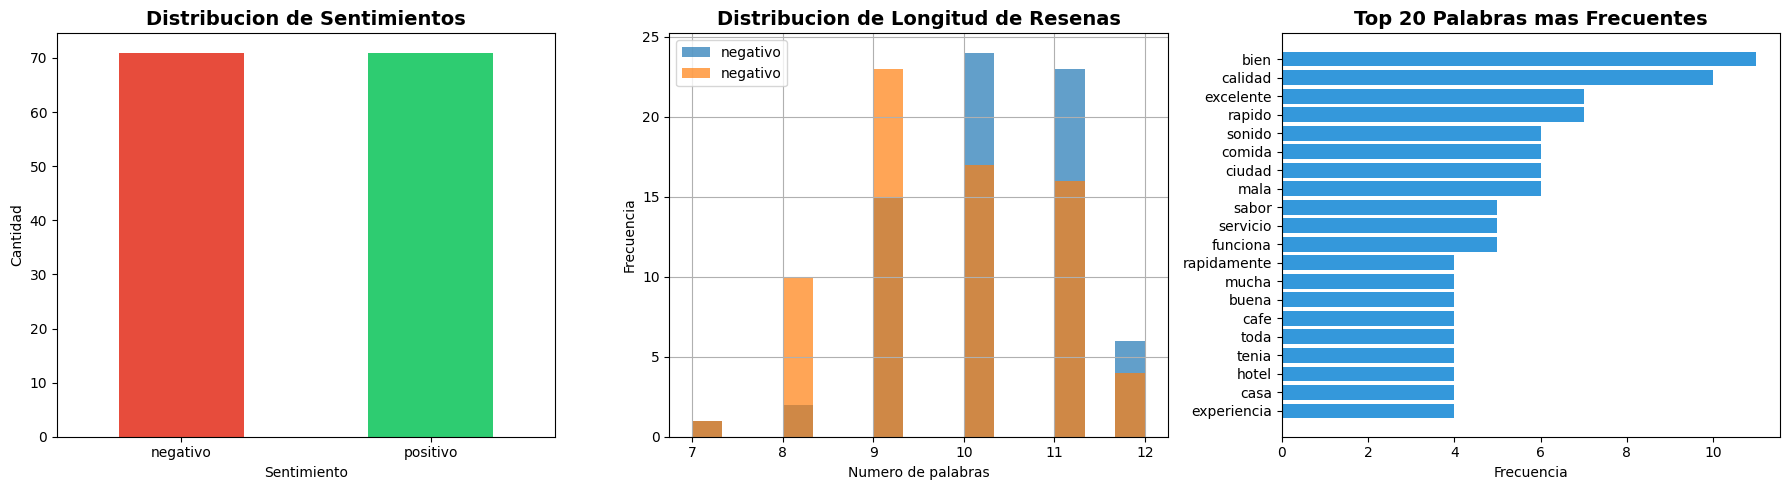


Estadisticas de longitud de resenas:
count    142.000000
mean       9.936620
std        1.137465
min        7.000000
25%        9.000000
50%       10.000000
75%       11.000000
max       12.000000
Name: num_palabras, dtype: float64


In [38]:
# Exploracion del dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribucion de sentimientos
colores = ['#e74c3c', '#2ecc71']
df['etiqueta'].value_counts().plot(kind='bar', ax=axes[0], color=colores)
axes[0].set_title('Distribucion de Sentimientos', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentimiento')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

# 2. Longitud de resenas (en palabras)
df['num_palabras'] = df['texto'].apply(lambda x: len(x.split()))
df.groupby('etiqueta')['num_palabras'].hist(ax=axes[1], alpha=0.7, bins=15, label=['negativo', 'positivo'])
axes[1].set_title('Distribucion de Longitud de Resenas', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Numero de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# 3. Palabras mas frecuentes
stop_words_es = set(stopwords.words('spanish'))
todas_palabras = []
for texto in df['texto']:
    palabras = texto.lower().split()
    todas_palabras.extend([p for p in palabras if p not in stop_words_es and len(p) > 2])

conteo = Counter(todas_palabras)
top_20 = conteo.most_common(20)
palabras_top, frecuencias_top = zip(*top_20)
axes[2].barh(range(len(palabras_top)), frecuencias_top, color='#3498db')
axes[2].set_yticks(range(len(palabras_top)))
axes[2].set_yticklabels(palabras_top)
axes[2].set_title('Top 20 Palabras mas Frecuentes', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Frecuencia')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nEstadisticas de longitud de resenas:")
print(df['num_palabras'].describe())

---

## 4. Experimentacion Guiada

### Experimento 1: Disperso vs Denso - Visualizar la Diferencia

Antes de ver los embeddings, comprobemos empiricamente las **limitaciones de BoW** que mencionamos en la teoria.

In [6]:
# 10 oraciones para demostrar las limitaciones de BoW
# Las primeras 5 oraciones son sobre comida/restaurantes con diferentes palabras
# Las ultimas 5 son sobre tecnologia
oraciones = [
    "La comida estuvo deliciosa y el servicio excelente",         # 0 - restaurante positivo
    "Los platos estaban ricos y la atencion fue maravillosa",     # 1 - restaurante positivo (sinonimos)
    "La cena fue magnifica con sabores extraordinarios",          # 2 - restaurante positivo (sinonimos)
    "La comida estaba horrible y el servicio pesimo",             # 3 - restaurante negativo
    "Los alimentos tenian mal sabor y la atencion fue terrible",  # 4 - restaurante negativo
    "El telefono funciona rapido y la bateria dura mucho",        # 5 - tecnologia positivo
    "El celular es veloz y tiene gran autonomia de carga",        # 6 - tecnologia positivo (sinonimos)
    "La laptop es potente y tiene buen rendimiento",              # 7 - tecnologia positivo
    "El telefono es lento y la bateria se agota rapido",          # 8 - tecnologia negativo
    "El ordenador falla constantemente y es inestable",           # 9 - tecnologia negativo
]

# Crear representacion BoW
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(oraciones)

print("=== Representacion Bag of Words ===")
print(f"Forma de la matriz: {bow_matrix.shape}")
print(f"Numero de oraciones: {bow_matrix.shape[0]}")
print(f"Tamano del vocabulario: {bow_matrix.shape[1]}")
print(f"\nVocabulario (primeras 30 palabras):")
vocab = vectorizer.get_feature_names_out()
print(list(vocab[:30]))

# Mostrar la matriz dispersa
print(f"\n=== Matriz dispersa (observe la cantidad de ceros) ===")
bow_dense = bow_matrix.toarray()
df_bow = pd.DataFrame(bow_dense, columns=vocab,
                       index=[f"Orac_{i}" for i in range(len(oraciones))])
# Mostrar una parte de la matriz
print(df_bow.iloc[:, :15])

# Contar ceros
total_elementos = bow_dense.size
ceros = np.sum(bow_dense == 0)
print(f"\nTotal de elementos en la matriz: {total_elementos}")
print(f"Cantidad de ceros: {ceros}")
print(f"Porcentaje de ceros: {ceros/total_elementos*100:.1f}%")
print("\n>>> La matriz es MUY dispersa: la mayoria de valores son cero!")

=== Representacion Bag of Words ===
Forma de la matriz: (10, 52)
Numero de oraciones: 10
Tamano del vocabulario: 52

Vocabulario (primeras 30 palabras):
['agota', 'alimentos', 'atencion', 'autonomia', 'bateria', 'buen', 'carga', 'celular', 'cena', 'comida', 'con', 'constantemente', 'de', 'deliciosa', 'dura', 'el', 'es', 'estaba', 'estaban', 'estuvo', 'excelente', 'extraordinarios', 'falla', 'fue', 'funciona', 'gran', 'horrible', 'inestable', 'la', 'laptop']

=== Matriz dispersa (observe la cantidad de ceros) ===
        agota  alimentos  atencion  autonomia  bateria  buen  carga  celular  \
Orac_0      0          0         0          0        0     0      0        0   
Orac_1      0          0         1          0        0     0      0        0   
Orac_2      0          0         0          0        0     0      0        0   
Orac_3      0          0         0          0        0     0      0        0   
Orac_4      0          1         1          0        0     0      0        0   
Or

=== Similitud Coseno con BoW ===

Oracion 0 vs Oracion 1: similitud = 0.1336
  Restaurante positivo con palabras DIFERENTES
  "La comida estuvo deliciosa y el servicio excelente..."
  "Los platos estaban ricos y la atencion fue maravil..."

Oracion 0 vs Oracion 2: similitud = 0.1429
  Restaurante positivo con palabras MUY DIFERENTES
  "La comida estuvo deliciosa y el servicio excelente..."
  "La cena fue magnifica con sabores extraordinarios..."

Oracion 0 vs Oracion 3: similitud = 0.5714
  Restaurante positivo vs negativo con palabras SIMILARES
  "La comida estuvo deliciosa y el servicio excelente..."
  "La comida estaba horrible y el servicio pesimo..."

Oracion 1 vs Oracion 4: similitud = 0.4714
  Restaurante positivo vs negativo (sinonimos diferentes)
  "Los platos estaban ricos y la atencion fue maravil..."
  "Los alimentos tenian mal sabor y la atencion fue t..."

Oracion 5 vs Oracion 6: similitud = 0.1179
  Tecnologia positivo con palabras DIFERENTES
  "El telefono funciona rapi

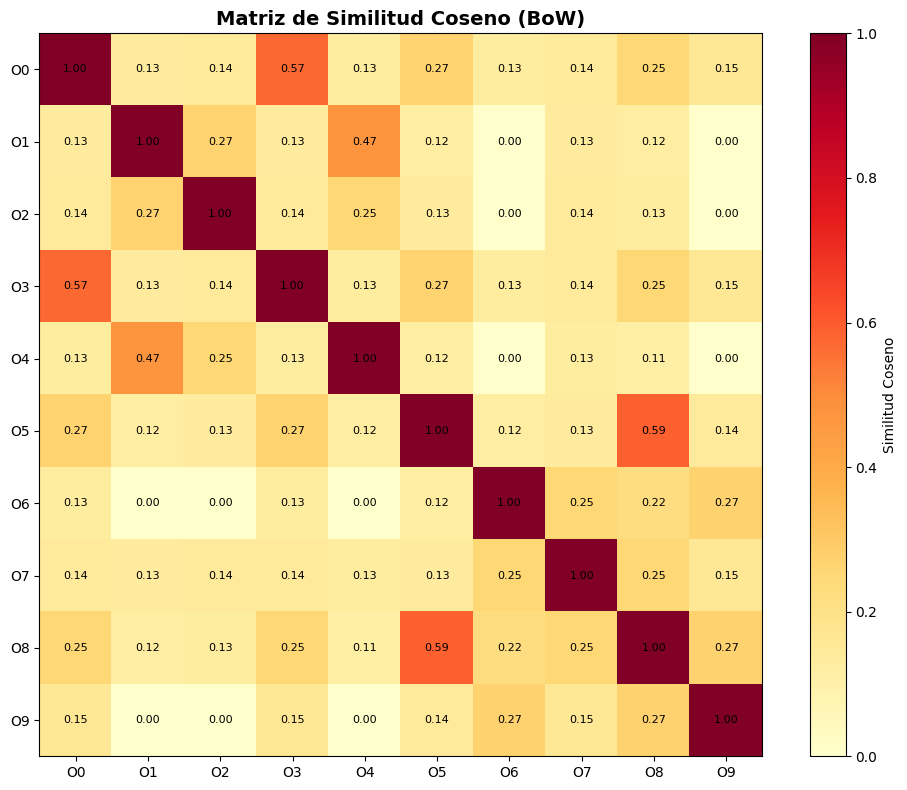


>>> PROBLEMA: Oraciones con significado similar pero palabras diferentes
    tienen BAJA similitud con BoW. Por ejemplo, Oracion 0 y 1 hablan de lo
    mismo (restaurante positivo) pero con palabras distintas.


In [7]:
# Calcular similitud coseno entre TODOS los pares de oraciones
sim_matrix = cosine_similarity(bow_matrix)

print("=== Similitud Coseno con BoW ===\n")

# Pares interesantes para analizar
pares = [
    (0, 1, "Restaurante positivo con palabras DIFERENTES"),
    (0, 2, "Restaurante positivo con palabras MUY DIFERENTES"),
    (0, 3, "Restaurante positivo vs negativo con palabras SIMILARES"),
    (1, 4, "Restaurante positivo vs negativo (sinonimos diferentes)"),
    (5, 6, "Tecnologia positivo con palabras DIFERENTES"),
    (5, 8, "Tecnologia positivo vs negativo con palabras SIMILARES"),
    (0, 5, "Restaurante vs Tecnologia (temas diferentes)"),
]

for i, j, descripcion in pares:
    sim = sim_matrix[i][j]
    print(f"Oracion {i} vs Oracion {j}: similitud = {sim:.4f}")
    print(f"  {descripcion}")
    print(f'  "{oraciones[i][:50]}..."')
    print(f'  "{oraciones[j][:50]}..."')
    print()

# Visualizar la matriz de similitud
plt.figure(figsize=(10, 8))
plt.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1)
plt.colorbar(label='Similitud Coseno')
plt.title('Matriz de Similitud Coseno (BoW)', fontsize=14, fontweight='bold')
plt.xticks(range(10), [f'O{i}' for i in range(10)])
plt.yticks(range(10), [f'O{i}' for i in range(10)])
for i in range(10):
    for j in range(10):
        plt.text(j, i, f'{sim_matrix[i][j]:.2f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print("\n>>> PROBLEMA: Oraciones con significado similar pero palabras diferentes")
print("    tienen BAJA similitud con BoW. Por ejemplo, Oracion 0 y 1 hablan de lo")
print("    mismo (restaurante positivo) pero con palabras distintas.")

### ✍️ Pregunta Experimento 1

**Que similitud coseno obtuviste entre oraciones con significado similar pero palabras diferentes (por ejemplo, Oracion 0 vs Oracion 1)? Por que BoW falla aqui? Explica con tus propias palabras por que dos oraciones que significan lo mismo pueden tener similitud cercana a cero en BoW.**
****
**RESPUESTA EXPERIMENTO 1**
SE OBTUVO UNA SIMILITUD COSENO ES DE UN VALOR MUY BAJO SIENDO MAS CERCANO A CERO ENTE LAS ORACIONES CON SIGINIFICADO SIMILAR Y PALABRAS DIFERENTES, UN EJEMPLO PUEDE SER.

#POR QUE BOW FALLA AQUI?

ORACION 0: LA COMIDA ESTUVO DELICIOSA Y EL SERVICIO FUE EXCELENTE
ORACION 1: LOS PLATOS ESTABAN RICOS Y LA ATENCION MARAVILLOSA
AL OBSERVAR LA MATRIZ QUE SE GENERA SE VE ASI:

###ORACION 0: COMIDA, DELICIOSA, EXCELENTE, SERVICIO
###ORACION 1: PLATOS, RICOS, ATENCION, MARAVILLOSA

AL REALIZAR ESTA REVISION SE VE QUE NO COMPARTEN COLUMNAS DESPUES QUE DESCARTAMOS ARTICULOS Y PREPOCISIONES QUE NO APORTAN MUCHO SIGNIFICADO. Y DESDE ESA PESPECTIVA LA DOS ORACIONES HABLAN DE TEMAS COMPLETAMENTE DIFERENTE PESE A QUE LAS DOS EXPRESAN UNA EXPERIENCIA POSITIVA EN UN RESTAURANTE. ESTO PASA PORQUE NO ENTIENDE DE SINONIMOS NI CONCEPTOS. LO UNICO QUE TIENE EN CUENTA SON PALABRAS QUE SE ESCRIBEN EXACTAMENTE IGUALES Y AL CAMBIAR EN CANTIDAD DE CARACTERES ORDEN Y LAS LETRAS INCLUIDAS YA LOS TOMA COMO CONTEXTOS TOTALMENTE DIFERENTE.



---

### Experimento 2: Entrenar Word2Vec Propio con Gensim

Ahora entrenaremos nuestro **propio modelo Word2Vec** usando el corpus de resenas en espanol. Veremos como, incluso con un corpus pequeno, el modelo captura relaciones semanticas.

In [8]:
# Preprocesamiento: tokenizar todas las resenas
def preprocesar_texto(texto):
    """Limpia y tokeniza un texto en espanol."""
    # Convertir a minusculas
    texto = texto.lower()
    # Eliminar caracteres especiales (mantener letras, numeros y espacios)
    texto = re.sub(r'[^a-zaeiounuA-Z0-9\s]', '', texto)
    # Tokenizar
    tokens = texto.split()
    # Eliminar stopwords y palabras muy cortas
    stop_words_es = set(stopwords.words('spanish'))
    tokens = [t for t in tokens if t not in stop_words_es and len(t) > 2]
    return tokens

# Crear corpus tokenizado (lista de listas de palabras)
corpus_tokenizado = [preprocesar_texto(texto) for texto in df['texto']]

print("=== Corpus tokenizado ===")
print(f"Numero de documentos: {len(corpus_tokenizado)}")
print(f"\nEjemplos de tokenizacion:")
for i in range(5):
    print(f"  Original: '{df['texto'].iloc[i][:60]}...'")
    print(f"  Tokens:   {corpus_tokenizado[i]}")
    print()

# Estadisticas del corpus
todas_palabras_corpus = [p for doc in corpus_tokenizado for p in doc]
vocab_unico = set(todas_palabras_corpus)
print(f"Total de tokens: {len(todas_palabras_corpus)}")
print(f"Vocabulario unico: {len(vocab_unico)} palabras")

=== Corpus tokenizado ===
Numero de documentos: 142

Ejemplos de tokenizacion:
  Original: 'Las toallas no absorben nada y se deshilachan rapidamente...'
  Tokens:   ['toallas', 'absorben', 'deshilachan', 'rapidamente']

  Original: 'La bocina portatil tiene un sonido increible para su tamano...'
  Tokens:   ['bocina', 'portatil', 'sonido', 'increible', 'tamano']

  Original: 'Los parlantes tienen un sonido horrible con mucha distorsion...'
  Tokens:   ['parlantes', 'sonido', 'horrible', 'mucha', 'distorsion']

  Original: 'La pasta estaba pasada de coccion y la salsa sin sabor...'
  Tokens:   ['pasta', 'pasada', 'coccion', 'salsa', 'sabor']

  Original: 'La lampara LED tiene buena iluminacion y consume poca energi...'
  Tokens:   ['lampara', 'led', 'buena', 'iluminacion', 'consume', 'poca', 'energia']

Total de tokens: 737
Vocabulario unico: 457 palabras


In [9]:
# Entrenar modelo Word2Vec con Gensim
print("=== Entrenando Word2Vec ===\n")

modelo_w2v = Word2Vec(
    sentences=corpus_tokenizado,   # Corpus tokenizado
    vector_size=100,               # Dimension de los embeddings
    window=5,                      # Tamano de la ventana de contexto
    min_count=2,                   # Ignorar palabras con frecuencia < 2
    workers=4,                     # Numero de hilos
    epochs=100,                    # Numero de epocas de entrenamiento
    sg=0,                          # 0=CBOW, 1=Skip-gram
    seed=SEED
)

print(f"Modelo entrenado exitosamente!")
print(f"Tamano del vocabulario del modelo: {len(modelo_w2v.wv)}")
print(f"Dimension de los vectores: {modelo_w2v.wv.vector_size}")

# Mostrar algunas palabras del vocabulario
print(f"\nAlgunas palabras del vocabulario:")
palabras_vocab = list(modelo_w2v.wv.key_to_index.keys())[:30]
print(palabras_vocab)

=== Entrenando Word2Vec ===

Modelo entrenado exitosamente!
Tamano del vocabulario del modelo: 171
Dimension de los vectores: 100

Algunas palabras del vocabulario:
['bien', 'calidad', 'rapido', 'excelente', 'mala', 'ciudad', 'comida', 'sonido', 'funciona', 'servicio', 'sabor', 'hace', 'bateria', 'restaurante', 'constantemente', 'duro', 'experiencia', 'casa', 'hotel', 'tenia', 'toda', 'cafe', 'buena', 'mucha', 'rapidamente', 'uso', 'postre', 'comodo', 'precios', 'demasiado']


In [10]:
# Explorar el modelo: palabras mas similares
print("=== Explorando relaciones semanticas ===\n")

palabras_prueba = ['excelente', 'terrible', 'comida', 'telefono', 'comodo', 'rapido']

for palabra in palabras_prueba:
    if palabra in modelo_w2v.wv:
        similares = modelo_w2v.wv.most_similar(palabra, topn=5)
        print(f"Palabras mas similares a '{palabra}':")
        for p, sim in similares:
            print(f"  {p:20s} -> similitud: {sim:.4f}")
        print()
    else:
        print(f"'{palabra}' no esta en el vocabulario del modelo\n")

=== Explorando relaciones semanticas ===

Palabras mas similares a 'excelente':
  bien                 -> similitud: 0.9503
  dormir               -> similitud: 0.9437
  bloquean             -> similitud: 0.9421
  sonido               -> similitud: 0.9411
  constantemente       -> similitud: 0.9396

Palabras mas similares a 'terrible':
  bien                 -> similitud: 0.9478
  funciona             -> similitud: 0.9367
  demasiado            -> similitud: 0.9357
  reloj                -> similitud: 0.9328
  funciones            -> similitud: 0.9326

Palabras mas similares a 'comida':
  bien                 -> similitud: 0.9329
  manera               -> similitud: 0.9294
  muchas               -> similitud: 0.9270
  sonido               -> similitud: 0.9244
  calidad              -> similitud: 0.9244

Palabras mas similares a 'telefono':
  bien                 -> similitud: 0.9345
  constantemente       -> similitud: 0.9226
  bateria              -> similitud: 0.9223
  casa          

In [11]:
# Calcular similitud entre pares de palabras
print("=== Similitud entre pares de palabras ===\n")

pares_palabras = [
    ('bueno', 'excelente'),
    ('bueno', 'malo'),
    ('comida', 'sabor'),
    ('telefono', 'bateria'),
    ('comodo', 'incomodo'),
    ('rapido', 'lento'),
]

for p1, p2 in pares_palabras:
    if p1 in modelo_w2v.wv and p2 in modelo_w2v.wv:
        sim = modelo_w2v.wv.similarity(p1, p2)
        print(f"Similitud('{p1}', '{p2}'): {sim:.4f}")
    else:
        faltante = p1 if p1 not in modelo_w2v.wv else p2
        print(f"'{faltante}' no esta en el vocabulario")

print("\n>>> Nota: Con un corpus pequeno, las relaciones pueden no ser perfectas.")
print("    Con corpus mas grandes, Word2Vec captura semantica mucho mejor.")

=== Similitud entre pares de palabras ===

'bueno' no esta en el vocabulario
'bueno' no esta en el vocabulario
Similitud('comida', 'sabor'): 0.9237
Similitud('telefono', 'bateria'): 0.9223
Similitud('comodo', 'incomodo'): 0.9096
'lento' no esta en el vocabulario

>>> Nota: Con un corpus pequeno, las relaciones pueden no ser perfectas.
    Con corpus mas grandes, Word2Vec captura semantica mucho mejor.


In [12]:
# Probar relaciones analogicas (positivo - negativo)
print("=== Relaciones analogicas ===\n")

# Intentar: bueno + que? = malo + que?
try:
    resultado = modelo_w2v.wv.most_similar(positive=['bueno'], negative=['malo'], topn=5)
    print("Palabras asociadas con 'bueno' pero no con 'malo':")
    for p, sim in resultado:
        print(f"  {p:20s} -> similitud: {sim:.4f}")
except KeyError as e:
    print(f"Palabra no encontrada: {e}")

print()

try:
    resultado = modelo_w2v.wv.most_similar(positive=['malo'], negative=['bueno'], topn=5)
    print("Palabras asociadas con 'malo' pero no con 'bueno':")
    for p, sim in resultado:
        print(f"  {p:20s} -> similitud: {sim:.4f}")
except KeyError as e:
    print(f"Palabra no encontrada: {e}")

=== Relaciones analogicas ===

Palabra no encontrada: "Key 'bueno' not present in vocabulary"

Palabra no encontrada: "Key 'malo' not present in vocabulary"


### ✍️ Pregunta Experimento 2

**Las palabras mas similares a 'excelente' tienen sentido? Y las mas similares a 'terrible'? El modelo capturo la semantica? Si algunas relaciones no son perfectas, a que crees que se debe? (Pista: piensa en el tamano del corpus)**

****
**RESPUESTA EXPERIMENTO 2**

LAS PALABRAS QUE SON SIMILARES A EXCELENTE TIENEN SENTIDO: LA RESPUESTA ES NO, SOLO BIEN TIENE SENTIDO POR SU SIGNIFICADO. DORMIR Y BLOQUEAN NO.

LAS PALABRAS QUE SON SIMILARES A TERRIBLE TIENEN SENTIDO: LA RESPUESTA ES NO, BIEN APARECE NUEVAMENTE COMO SIMILAR A TERRIBLE TAMBIEN LO QUE ES UN ERROR YA QUE SON OPUESTOS SUS SIGNIFICADOS.

EL MODELO CAPTURO LAS SEMANTICAS: LA RESPUESTA ES NO, YA QUE LAS RELACIONES NO SON COHERENTES

POR QUE: ESTO SE DA PORQUE EL CORPUS ES MUY PEQUEÑO TENEMOS 142 RESEÑAS Y 737 PALABRAS. PERO WORD2VEC NECESITA MUCHOS DATOS PARA APRENDER BIEN YA QUE CON POCOS DATOS TIENDE A APRENEDER RELACIONES EQUIVOCADAS.


---

### Experimento 3: CBOW vs Skip-gram

Comparemos las dos arquitecturas de Word2Vec: **CBOW** (sg=0) y **Skip-gram** (sg=1).

In [13]:
# Entrenar modelo CBOW
print("=== Entrenando CBOW (sg=0) ===")
inicio_cbow = time.time()
modelo_cbow = Word2Vec(
    sentences=corpus_tokenizado,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=100,
    sg=0,  # CBOW
    seed=SEED
)
tiempo_cbow = time.time() - inicio_cbow
print(f"Tiempo de entrenamiento CBOW: {tiempo_cbow:.2f} segundos")

# Entrenar modelo Skip-gram
print("\n=== Entrenando Skip-gram (sg=1) ===")
inicio_sg = time.time()
modelo_skipgram = Word2Vec(
    sentences=corpus_tokenizado,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=100,
    sg=1,  # Skip-gram
    seed=SEED
)
tiempo_sg = time.time() - inicio_sg
print(f"Tiempo de entrenamiento Skip-gram: {tiempo_sg:.2f} segundos")

print(f"\n=== Comparacion de tiempos ===")
print(f"CBOW:      {tiempo_cbow:.2f}s")
print(f"Skip-gram: {tiempo_sg:.2f}s")
print(f"Diferencia: Skip-gram es {tiempo_sg/tiempo_cbow:.1f}x respecto a CBOW")

=== Entrenando CBOW (sg=0) ===
Tiempo de entrenamiento CBOW: 0.40 segundos

=== Entrenando Skip-gram (sg=1) ===
Tiempo de entrenamiento Skip-gram: 0.43 segundos

=== Comparacion de tiempos ===
CBOW:      0.40s
Skip-gram: 0.43s
Diferencia: Skip-gram es 1.1x respecto a CBOW


In [14]:
# Comparar resultados: palabras mas similares
palabras_comparar = ['excelente', 'terrible', 'comida', 'rapido']

print("=== Comparacion CBOW vs Skip-gram ===\n")
for palabra in palabras_comparar:
    if palabra in modelo_cbow.wv and palabra in modelo_skipgram.wv:
        sim_cbow = modelo_cbow.wv.most_similar(palabra, topn=5)
        sim_sg = modelo_skipgram.wv.most_similar(palabra, topn=5)

        print(f"Palabra: '{palabra}'")
        print(f"  {'CBOW':30s} | {'Skip-gram':30s}")
        print(f"  {'-'*30} | {'-'*30}")
        for (p1, s1), (p2, s2) in zip(sim_cbow, sim_sg):
            print(f"  {p1:20s} ({s1:.3f})  | {p2:20s} ({s2:.3f})")
        print()
    else:
        print(f"'{palabra}' no esta en ambos vocabularios\n")

=== Comparacion CBOW vs Skip-gram ===

Palabra: 'excelente'
  CBOW                           | Skip-gram                     
  ------------------------------ | ------------------------------
  bien                 (0.950)  | bien                 (0.994)
  dormir               (0.944)  | sonido               (0.994)
  bloquean             (0.942)  | rapido               (0.994)
  sonido               (0.941)  | dormir               (0.993)
  constantemente       (0.940)  | calidad              (0.993)

Palabra: 'terrible'
  CBOW                           | Skip-gram                     
  ------------------------------ | ------------------------------
  bien                 (0.948)  | bien                 (0.994)
  funciona             (0.937)  | demasiado            (0.994)
  demasiado            (0.936)  | carne                (0.993)
  reloj                (0.933)  | rapido               (0.993)
  funciones            (0.933)  | funciona             (0.993)

Palabra: 'comida'
  CBOW

### ✍️ Pregunta Experimento 3

**Cual modelo dio resultados mas intuitivos (CBOW o Skip-gram)? Cual fue mas rapido de entrenar? Segun la teoria, cuando recomiendas usar cada uno? (Pista: piensa en el tamano del corpus y la frecuencia de las palabras)**

****
**RESPUESTA EXPERIMENTO 3**
CUAL MODELO DIO MAS RESULTADOS INTUITIVOS: A PESAR QUE AMBOS ARROJARON RESULTADOS SIMILARES Y NO TAN BUENOS PUESTO QUE LA PALABRA BIEN APARECE COMO SIMILAR A VARIAS. SKIP-GRAM ESTUVO POR ENCIMA DE CBOW PUES LOGRO CONECTAR ADJETIVOS COMO CALIDAD Y SABOR Y POR OTRO LADO CBOW SE ENREDO INCLUYENDO PALABRAS COMO MANERA Y MUCHAS.

CUAL FUE MAS RAPIDO DE ENTRENAR: AMBOS FUERON CASI IGUALES LA DIFERENCIA FUE MUY MINIMA PERO CBOW FUE UN POCO MAS RAPIDO QUE SKIP-GRAM

SEGUN LA TEORIA CUANDO RECOMIENDAS USAR CADA UNO:

CBOW LO RECOMIENDO USAR PARA LOS CORPUS GRANDES Y PALABRAS DE USO FRECUENTE PUES ESTE ES MAS RAPIDO Y FUNCIONA BIEN CUANDO HAY MUCHA CANTIDAD DE DATOS.

SKIP-GRAM LO RECOMIENDO PARA CORPUS PEQUEÑOS O PALABRAS RARAS O POCO COMUNES PUES AUNQUE ES MAS LENTO APRENDE MEJOR CUANDO LOS DATOS SON LIMITADOS.



---

### Experimento 4: Efecto de los Hiperparametros

Exploremos como afectan el **tamano del vector** (vector_size) y el **tamano de la ventana** (window) a la calidad de los embeddings.

In [15]:
# Variar vector_size
print("=== Efecto del tamano del vector (vector_size) ===\n")

tamaños_vector = [50, 100, 200, 300]
modelos_vs = {}
palabra_prueba = 'excelente'

for vs in tamaños_vector:
    modelo_temp = Word2Vec(
        sentences=corpus_tokenizado,
        vector_size=vs,
        window=5,
        min_count=2,
        workers=4,
        epochs=100,
        sg=1,
        seed=SEED
    )
    modelos_vs[vs] = modelo_temp

    if palabra_prueba in modelo_temp.wv:
        similares = modelo_temp.wv.most_similar(palabra_prueba, topn=5)
        print(f"vector_size={vs}:")
        print(f"  Mas similares a '{palabra_prueba}': ", end="")
        print(", ".join([f"{p}({s:.3f})" for p, s in similares]))
    print()

=== Efecto del tamano del vector (vector_size) ===

vector_size=50:
  Mas similares a 'excelente': bateria(0.995), constantemente(0.995), calidad(0.993), toda(0.993), rapido(0.993)

vector_size=100:
  Mas similares a 'excelente': bien(0.994), sonido(0.994), rapido(0.994), dormir(0.993), calidad(0.993)

vector_size=200:
  Mas similares a 'excelente': bien(0.996), calidad(0.996), bateria(0.996), funciona(0.996), buena(0.996)

vector_size=300:
  Mas similares a 'excelente': bien(0.997), sonido(0.996), ingredientes(0.996), bateria(0.996), constantemente(0.996)



In [16]:
# Variar window (tamano de ventana de contexto)
print("=== Efecto del tamano de ventana (window) ===\n")

tamanos_ventana = [2, 5, 10]
modelos_win = {}
palabra_prueba = 'comida'

for win in tamanos_ventana:
    modelo_temp = Word2Vec(
        sentences=corpus_tokenizado,
        vector_size=100,
        window=win,
        min_count=2,
        workers=4,
        epochs=100,
        sg=1,
        seed=SEED
    )
    modelos_win[win] = modelo_temp

    if palabra_prueba in modelo_temp.wv:
        similares = modelo_temp.wv.most_similar(palabra_prueba, topn=5)
        print(f"window={win}:")
        print(f"  Mas similares a '{palabra_prueba}': ", end="")
        print(", ".join([f"{p}({s:.3f})" for p, s in similares]))
    print()

print(">>> Ventanas pequenas (2-3): capturan relaciones SINTACTICAS (palabras intercambiables)")
print(">>> Ventanas grandes (8-10): capturan relaciones SEMANTICAS (palabras del mismo tema)")

=== Efecto del tamano de ventana (window) ===

window=2:
  Mas similares a 'comida': manera(0.981), calidad(0.981), bien(0.980), sonido(0.980), constantemente(0.979)

window=5:
  Mas similares a 'comida': bien(0.994), calidad(0.993), sonido(0.993), sabor(0.993), tenia(0.993)

window=10:
  Mas similares a 'comida': bien(0.995), sabor(0.995), calidad(0.995), rapido(0.995), tenia(0.994)

>>> Ventanas pequenas (2-3): capturan relaciones SINTACTICAS (palabras intercambiables)
>>> Ventanas grandes (8-10): capturan relaciones SEMANTICAS (palabras del mismo tema)


### ✍️ Pregunta Experimento 4

**Que tamano de vector y ventana dio mejores resultados semanticos? Hay un punto de rendimiento decreciente donde aumentar las dimensiones ya no mejora (o incluso empeora) los resultados? Explica por que un vector_size=300 podria ser contraproducente para un corpus pequeno.**

****
**RESPUESTA EXPERIMENTO 4**


EL MEJOR TAMAÑO DE VECTOR: FUE VECTOR_SIZE=100 QUE LOGRO ASOCIACIONES MUY INTUITIVAS PARA LA PALABRA EXCELENTE Y LA UNIO COHERENTEMENTE CON BIEN, SONIDO Y CALIDAD.

LA MEJOR VENTANA FUE: LA 5 O LA 10 PUESTO QUE AL AGRANDAR LA VENTANA, EL MODELO LOGRO CAPTURAR RELACIONES SEMANTICAS PORQUE RECONOCIO EL TEMA PARA EL CASO DE LA ORACION COMPLETA Y EL EJEMPLO PERFECTO FUE LA PALABRA COMIDA, QUE  SE CONECTO DIRECTAMENTE CON SABOR, ALGO QUE LA VENTANA PEQUEÑA 2 NO LOGRO CONSERVAR.

HAY UN PUNTO DE RENDIMIENTO DECRECIENTE: LA RESPUESTA ES SI EN LA INTELIGENCIA ARTIFICIAL, SOLO DEBEMOS TENER EN CUENTA QUE SI  SUBIMOS EL VECTOR A 200 O 300 DIMENSIONES IMPACTARA EL RENDIMIENTO Y LOS RESULTADOS VAN A DETERIORARSE PORQUE EL MODELO EMPIEZA A INVENTAR RELACIONES Y PERDER COHERENCIA.

POR QUÉ VECTOR_SIZE=300 ES CONTRAPRODUCENTE PARA UN CORPUS PEQUEÑO:

TENDRA MAS PARAMETROS PARA APRENDER Y EN UN VECTOR DE 300 DIMENSIONES SE NECESITARAN MAS EJEMPLOS PARA  DARLE SENTIDO Y CONTEXTO A CADA DIMENSION

RIESGO DE SOBREAJUSTE CON POCOS DATOS EL MODELO EMPIEZA A MEMORIZAR LAS COINCIDENCIAS POR AZAR EN LUGAR DE APRENDER REGLAS GENERALES

VECTORES VACIOS Y RUIDOSOS CON MUCHAS DIMENSIONES QUE TERMINAN EN VALORES ALEATORIOS PORQUE NO HAY SUFICIENTES CONTEXTOS PARA LLENARLAS CON INFORMACION QUE SEA UTIL

---

### Experimento 5: Visualizar Embeddings con t-SNE

**t-SNE** (t-distributed Stochastic Neighbor Embedding) es una tecnica de reduccion de dimensionalidad que nos permite **visualizar** vectores de alta dimensionalidad en 2D. Es perfecta para explorar clusters en los embeddings.

In [17]:
# Obtener las palabras mas frecuentes del modelo
# Usaremos el modelo Skip-gram con vector_size=100
modelo_viz = modelo_skipgram

# Tomar las 150 palabras mas frecuentes que esten en el modelo
conteo_palabras = Counter(todas_palabras_corpus)
palabras_frecuentes = []
vectores_frecuentes = []

for palabra, freq in conteo_palabras.most_common(200):
    if palabra in modelo_viz.wv and len(palabra) > 2:
        palabras_frecuentes.append(palabra)
        vectores_frecuentes.append(modelo_viz.wv[palabra])
    if len(palabras_frecuentes) >= 150:
        break

vectores_array = np.array(vectores_frecuentes)
print(f"Numero de palabras seleccionadas: {len(palabras_frecuentes)}")
print(f"Forma de la matriz de vectores: {vectores_array.shape}")

# Aplicar t-SNE para reducir de 100 dimensiones a 2
print("\nAplicando t-SNE (esto puede tomar unos segundos)...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
vectores_2d = tsne.fit_transform(vectores_array)
print(f"Forma despues de t-SNE: {vectores_2d.shape}")

Numero de palabras seleccionadas: 150
Forma de la matriz de vectores: (150, 100)

Aplicando t-SNE (esto puede tomar unos segundos)...
Forma despues de t-SNE: (150, 2)


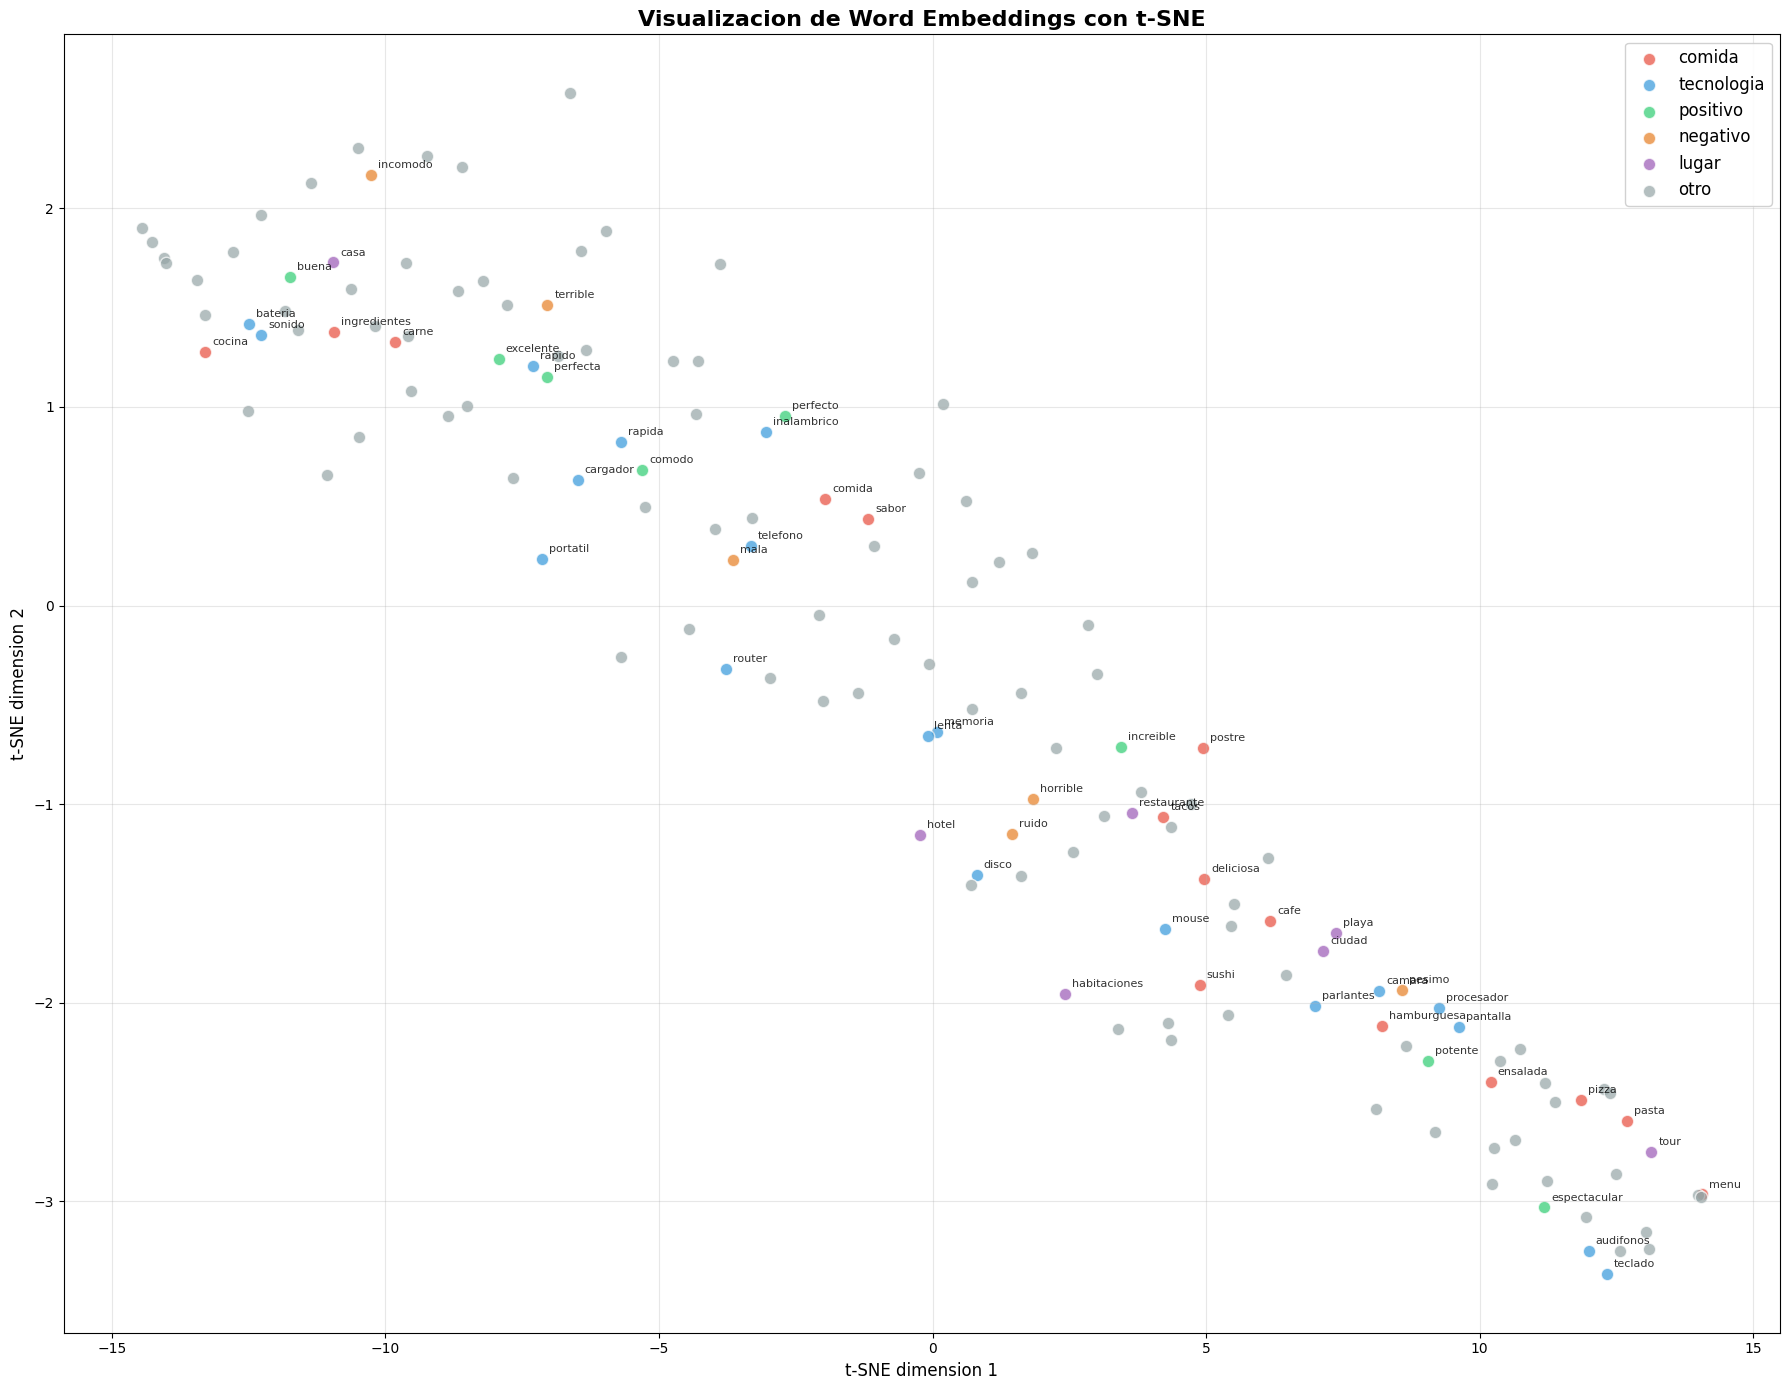

>>> Observa como las palabras del mismo campo semantico tienden a agruparse.
>>> Los clusters reflejan las relaciones semanticas aprendidas por Word2Vec.


In [18]:
# Visualizar los embeddings en 2D
plt.figure(figsize=(18, 14))

# Definir categorias semanticas manualmente para colorear
categorias_palabras = {
    'comida': ['comida', 'sabor', 'deliciosa', 'pizza', 'cafe', 'pasta', 'carne',
               'sushi', 'hamburguesa', 'postre', 'ensalada', 'platos', 'menu',
               'ingredientes', 'tacos', 'cena', 'cocina', 'fresca', 'ricos'],
    'tecnologia': ['telefono', 'laptop', 'pantalla', 'bateria', 'teclado', 'mouse',
                   'sonido', 'camara', 'impresora', 'procesador', 'memoria', 'router',
                   'parlantes', 'celular', 'disco', 'audifonos', 'cargador', 'portatil',
                   'inalambrico', 'rapida', 'lenta', 'rapido', 'lento'],
    'positivo': ['excelente', 'perfecta', 'increible', 'maravillosa', 'fantastico',
                 'magnifico', 'espectacular', 'delicioso', 'comodo', 'hermoso',
                 'potente', 'buena', 'mejor', 'bueno', 'perfecto'],
    'negativo': ['terrible', 'horrible', 'pesimo', 'malo', 'mala', 'peor', 'sucio',
                 'incomodo', 'lenta', 'falla', 'ruido', 'problema', 'danado'],
    'lugar': ['hotel', 'restaurante', 'playa', 'ciudad', 'museo', 'habitaciones',
              'casa', 'tour', 'montana'],
}

colores_cat = {
    'comida': '#e74c3c',
    'tecnologia': '#3498db',
    'positivo': '#2ecc71',
    'negativo': '#e67e22',
    'lugar': '#9b59b6',
    'otro': '#95a5a6'
}

# Asignar categoria a cada palabra
categorias = []
for palabra in palabras_frecuentes:
    cat_asignada = 'otro'
    for cat, palabras_cat in categorias_palabras.items():
        if palabra in palabras_cat:
            cat_asignada = cat
            break
    categorias.append(cat_asignada)

# Graficar por categoria
for cat in colores_cat:
    indices = [i for i, c in enumerate(categorias) if c == cat]
    if indices:
        plt.scatter(vectores_2d[indices, 0], vectores_2d[indices, 1],
                   c=colores_cat[cat], label=cat, alpha=0.7, s=80, edgecolors='white')

# Agregar etiquetas de palabras
for i, palabra in enumerate(palabras_frecuentes):
    if categorias[i] != 'otro':  # Solo etiquetar palabras con categoria
        plt.annotate(palabra, (vectores_2d[i, 0], vectores_2d[i, 1]),
                    fontsize=8, alpha=0.8,
                    xytext=(5, 5), textcoords='offset points')

plt.title('Visualizacion de Word Embeddings con t-SNE', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE dimension 1', fontsize=12)
plt.ylabel('t-SNE dimension 2', fontsize=12)
plt.legend(fontsize=12, loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(">>> Observa como las palabras del mismo campo semantico tienden a agruparse.")
print(">>> Los clusters reflejan las relaciones semanticas aprendidas por Word2Vec.")

### ✍️ Pregunta Experimento 5

**Que clusters de palabras puedes identificar en la visualizacion t-SNE? Tiene sentido que esas palabras esten juntas? Describe al menos 3 clusters que observes y explica por que crees que se agruparon asi.**

****
**RESPUESTA EXPERIMENTO 5**

LAS PALABRAS QUE SE IDENTIFICAN SE ACOMODARON EN UNA LINEA DIAGONAL O CURVA CONTINUA. ESTO TIENE MUCHO SENTIDO PUES POR COMO SE UBICARON ALGUNAS DE ELLAS EL ALGORITMO DETECTO OCURRENCIAS MUY CLARAS EN LOS DATOS.

GRUPOS O CLUSTERS CLAVES QUE SE ALINEARON

PALABRAS QUE SE IDENTIFICAN: COCINA, INGREDIENTES, CARNE, SONIDO, BATERÍA, BUENA

SU AGRUPACION QUEDO ASI PORQUE COMPARTEN LA MISMA ESTRUCTURA EN LAS RESEÑAS Y EL MODELO LOS UNE PORQUE FUNCIONAN COMO SUJETOS QUE RECIBEN ADJETIVOS

PALABRAS QUE SE IDENTIFICAN: ENSALADA, PIZZA, PASTA, MENU, ESPECTACULAR

TODAS ESTAS PALABRAS ESTAN EN EL DOMINIO DE RESTAURANTES Y PLATOS ESPECIFICOS. WORD2VEC SE DIO CUENTA QUE LOS USUARIOS NOMBRAN ESTOS ALIMENTOS EN LAS RESEÑAS CON PALABRAS COMO ESPECTACULAR

PALABRAS QUE SE IDENTIFICAN: AUDIFONOS, TECLADO, PROCESADOR, PESIMO, HAMBURGUESA

EL MODELO ACOMODO LOS APARATOS TECNOLOGICOS PUESTO QUE SE REPITEN EN LAS QUEJAS Y SE AGRUPAN AHI PORQUE DETECTO QUE ERAN LOS FINALES DONDE LA GENTE EVALUABA DIRECTAMENTE EL RENDIMIENTO DEL PRODUCTO.







---

### Experimento 6: Embeddings Pre-entrenados (fastText Espanol)

Los embeddings **pre-entrenados** fueron entrenados en corpus masivos (miles de millones de palabras). Capturan relaciones semanticas mucho mejor que nuestro modelo entrenado en 150 resenas.

Usaremos los embeddings de **fastText en espanol** disponibles a traves de Gensim. Nota: si la descarga es muy grande, usaremos una alternativa mas ligera.

In [19]:
# Descargar embeddings pre-entrenados de fastText en espanol
# Nota: La primera ejecucion descarga el modelo (~680MB). Puede tomar unos minutos.
print("=== Cargando embeddings pre-entrenados de fastText Espanol ===")
print("Nota: La primera ejecucion descarga el modelo. Esto puede tomar varios minutos...\n")

try:
    # Intentar cargar fastText espanol de gensim
    # Gensim ofrece modelos pre-entrenados descargables
    # Lista de modelos disponibles:
    print("Modelos disponibles en gensim.downloader:")
    info = api.info()
    modelos_disponibles = list(info['models'].keys())
    modelos_w2v = [m for m in modelos_disponibles if 'word2vec' in m.lower() or 'fast' in m.lower() or 'glove' in m.lower()]
    print(f"Modelos de embeddings: {modelos_w2v[:10]}")
    print()

    # Cargar un modelo pre-entrenado (usaremos glove-wiki-gigaword-100 como alternativa
    # ya que los modelos de fastText en espanol pueden ser muy pesados)
    # Si quieres fastText espanol completo, descomenta la linea alternativa

    print("Cargando modelo pre-entrenado (glove-wiki-gigaword-100)...")
    print("(Alternativa ligera para el entorno de clase)\n")
    modelo_pretrained = api.load("glove-wiki-gigaword-100")

    print(f"Modelo cargado exitosamente!")
    print(f"Vocabulario: {len(modelo_pretrained)} palabras")
    print(f"Dimensiones: {modelo_pretrained.vector_size}")

except Exception as e:
    print(f"Error al cargar modelo: {e}")
    print("\nAlternativa: Descargando modelo mas pequeno...")
    modelo_pretrained = api.load("glove-wiki-gigaword-50")
    print(f"Modelo alternativo cargado: {len(modelo_pretrained)} palabras, {modelo_pretrained.vector_size} dims")

=== Cargando embeddings pre-entrenados de fastText Espanol ===
Nota: La primera ejecucion descarga el modelo. Esto puede tomar varios minutos...

Modelos disponibles en gensim.downloader:
Modelos de embeddings: ['fasttext-wiki-news-subwords-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100']

Cargando modelo pre-entrenado (glove-wiki-gigaword-100)...
(Alternativa ligera para el entorno de clase)

[==================================================] 100.0% 128.1/128.1MB downloaded
Modelo cargado exitosamente!
Vocabulario: 400000 palabras
Dimensiones: 100


In [20]:
# Explorar los embeddings pre-entrenados
print("=== Explorando embeddings pre-entrenados ===\n")

# Nota: Como usamos GloVe en ingles, las consultas seran en ingles
# Para resaltar la diferencia, hacemos las analogias clasicas

# Palabras similares
palabras_ingles = ['excellent', 'terrible', 'food', 'phone', 'fast', 'hotel']
for palabra in palabras_ingles:
    if palabra in modelo_pretrained:
        similares = modelo_pretrained.most_similar(palabra, topn=5)
        print(f"Similares a '{palabra}':")
        for p, s in similares:
            print(f"  {p:20s} -> {s:.4f}")
        print()

print(">>> Nota: Los embeddings pre-entrenados capturan relaciones mucho mas ricas")
print("    porque fueron entrenados en corpus de miles de millones de palabras.")

=== Explorando embeddings pre-entrenados ===

Similares a 'excellent':
  good                 -> 0.7936
  quality              -> 0.7606
  terrific             -> 0.7416
  superb               -> 0.7403
  best                 -> 0.7288

Similares a 'terrible':
  horrible             -> 0.9195
  awful                -> 0.8742
  dreadful             -> 0.7822
  horrendous           -> 0.7782
  horrific             -> 0.7644

Similares a 'food':
  foods                -> 0.7469
  supplies             -> 0.7265
  products             -> 0.7225
  meat                 -> 0.7138
  supply               -> 0.6733

Similares a 'phone':
  telephone            -> 0.9113
  cellphone            -> 0.8122
  phones               -> 0.8031
  mobile               -> 0.7307
  mail                 -> 0.7292

Similares a 'fast':
  slow                 -> 0.7960
  faster               -> 0.7512
  pace                 -> 0.7463
  speed                -> 0.7133
  quick                -> 0.7107

Similares a 'h

In [21]:
# La famosa analogia: king - man + woman = queen
print("=== Analogias con embeddings pre-entrenados ===\n")

analogias = [
    (['king'], ['man'], ['woman'], "king - man + woman = ?  (esperado: queen)"),
    (['paris'], ['france'], ['italy'], "paris - france + italy = ?  (esperado: rome)"),
    (['walking'], ['walk'], ['swim'], "walking - walk + swim = ?  (esperado: swimming)"),
    (['better'], ['good'], ['bad'], "better - good + bad = ?  (esperado: worse)"),
    (['bigger'], ['big'], ['small'], "bigger - big + small = ?  (esperado: smaller)"),
]

for positivas, negativas_1, positivas_2, descripcion in analogias:
    try:
        resultado = modelo_pretrained.most_similar(
            positive=positivas + positivas_2,
            negative=negativas_1,
            topn=3
        )
        print(f"{descripcion}")
        for p, s in resultado:
            print(f"  -> {p:15s} (similitud: {s:.4f})")
        print()
    except KeyError as e:
        print(f"Palabra no encontrada: {e}\n")

print(">>> Estas analogias demuestran que los embeddings capturan relaciones")
print("    semanticas profundas de forma algebraica!")

=== Analogias con embeddings pre-entrenados ===

king - man + woman = ?  (esperado: queen)
  -> queen           (similitud: 0.7699)
  -> monarch         (similitud: 0.6843)
  -> throne          (similitud: 0.6756)

paris - france + italy = ?  (esperado: rome)
  -> rome            (similitud: 0.8190)
  -> milan           (similitud: 0.7376)
  -> naples          (similitud: 0.7118)

walking - walk + swim = ?  (esperado: swimming)
  -> swimming        (similitud: 0.8009)
  -> surfing         (similitud: 0.6603)
  -> swam            (similitud: 0.6448)

better - good + bad = ?  (esperado: worse)
  -> worse           (similitud: 0.8443)
  -> too             (similitud: 0.7491)
  -> even            (similitud: 0.7306)

bigger - big + small = ?  (esperado: smaller)
  -> larger          (similitud: 0.8925)
  -> smaller         (similitud: 0.8694)
  -> large           (similitud: 0.7933)

>>> Estas analogias demuestran que los embeddings capturan relaciones
    semanticas profundas de forma alg

In [22]:
# Comparar embeddings propios vs pre-entrenados
print("=== Comparacion: Embeddings propios vs Pre-entrenados ===\n")

# Para la comparacion usaremos palabras que existan en ambos modelos
# Nuestro modelo esta en espanol y el pre-entrenado en ingles,
# asi que comparamos la CALIDAD de las relaciones semanticas

print("--- Modelo PROPIO (espanol, 150 resenas) ---")
palabras_propio = ['excelente', 'terrible', 'comida']
for palabra in palabras_propio:
    if palabra in modelo_w2v.wv:
        similares = modelo_w2v.wv.most_similar(palabra, topn=3)
        print(f"  '{palabra}': {[(p, round(s,3)) for p,s in similares]}")

print(f"\n--- Modelo PRE-ENTRENADO (ingles, billones de palabras) ---")
palabras_pre = ['excellent', 'terrible', 'food']
for palabra in palabras_pre:
    if palabra in modelo_pretrained:
        similares = modelo_pretrained.most_similar(palabra, topn=3)
        print(f"  '{palabra}': {[(p, round(s,3)) for p,s in similares]}")

print(f"\n>>> Los embeddings pre-entrenados dan resultados mucho mas ricos y precisos")
print(f"    porque fueron entrenados en corpus enormes con contextos variados.")
print(f"    Nuestro modelo propio solo ha visto 150 resenas cortas.")

=== Comparacion: Embeddings propios vs Pre-entrenados ===

--- Modelo PROPIO (espanol, 150 resenas) ---
  'excelente': [('bien', 0.95), ('dormir', 0.944), ('bloquean', 0.942)]
  'terrible': [('bien', 0.948), ('funciona', 0.937), ('demasiado', 0.936)]
  'comida': [('bien', 0.933), ('manera', 0.929), ('muchas', 0.927)]

--- Modelo PRE-ENTRENADO (ingles, billones de palabras) ---
  'excellent': [('good', 0.794), ('quality', 0.761), ('terrific', 0.742)]
  'terrible': [('horrible', 0.919), ('awful', 0.874), ('dreadful', 0.782)]
  'food': [('foods', 0.747), ('supplies', 0.726), ('products', 0.723)]

>>> Los embeddings pre-entrenados dan resultados mucho mas ricos y precisos
    porque fueron entrenados en corpus enormes con contextos variados.
    Nuestro modelo propio solo ha visto 150 resenas cortas.


### ✍️ Pregunta Experimento 6

**Los embeddings pre-entrenados son mejores que los entrenados en nuestro corpus pequeno? Por que? Que ventajas tiene usar embeddings pre-entrenados? En que situaciones podria ser mejor entrenar embeddings propios? (Pista: piensa en vocabulario especializado como terminos medicos o legales)**

****
**RESPUESTA EXPERIMENTO 6**

LOS EMBEDDINGS PREENTRENADOS SON MEJORES QUE LOS ENTRENADOS EN NUESTRO CORPUS PEQUEÑO: LA RESPUESTA ES SI SON MEJORES PUES NUESTRO MODELO ARROJA RELACIONES MENOS ACERTADAS MIENTRAS QUE EL MODELO PRE-ENTRENADO MOSTRO RELACIONES MAS COHERENTES.

POR QUE: PORQUE EL MODELO PREENTRENADO SE ALIMENTO DE MUCHAS PALABRAS Y LOGRO EXPANDIR SU VOCABULARIO A 400000 PALABRAS UNICAS, MIENTRAS EL NUESTRO SOLO LOGRO CONFIGURAR 171

VENTAJAS EMVEDDINGS PREENTRENADOS: AHORRO DE TIEMPO Y RECURSOS, MAYOR CALIDAD, VOCABULARIO ENORME, TRANSFERENCIA DE APRENDIZAJE

EN QUE SITUACIONES PODRIA SER MEJOR ENTRENAR EMBEDDINSG PROPIOS: ESTA OPCION LA PODEMOS TOMAR CUANDO TRABAJAMOS CON VOCABULARIOS ESPECIALIZADOS COMO POR EJEMPLO SE VE EN EL MUNDO MEDICO CON NOMBRES DE EMFERMEDADES O COMPUESTOS QUIMICOS RAROS



---

### Experimento 7: Clasificacion de Sentimiento con Embeddings + PyTorch

Ahora usaremos los embeddings como **primera capa de una red neuronal** para clasificar sentimiento. Compararemos:
- **Opcion A:** Embeddings aleatorios (aprendidos desde cero)
- **Opcion B:** Embeddings inicializados con Word2Vec pre-entrenado

In [23]:
# Preparar los datos para PyTorch
# 1. Construir vocabulario
print("=== Preparando datos para PyTorch ===\n")

# Tokenizar todos los textos
textos_tokenizados = [preprocesar_texto(t) for t in df['texto']]

# Construir vocabulario con las palabras del corpus
word_counts = Counter([w for tokens in textos_tokenizados for w in tokens])
# Tokens especiales: <PAD>=0, <UNK>=1
vocab = {'<PAD>': 0, '<UNK>': 1}
for palabra, count in word_counts.most_common():
    if count >= 1:  # incluir todas las palabras
        vocab[palabra] = len(vocab)

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 100
MAX_LEN = 20  # Longitud maxima de secuencia (en tokens)

print(f"Tamano del vocabulario: {VOCAB_SIZE}")
print(f"Dimension de embeddings: {EMBEDDING_DIM}")
print(f"Longitud maxima de secuencia: {MAX_LEN}")

# 2. Convertir textos a secuencias de indices
def texto_a_indices(tokens, vocab, max_len):
    """Convierte una lista de tokens a indices, con padding."""
    indices = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    # Truncar si es mas largo que max_len
    if len(indices) > max_len:
        indices = indices[:max_len]
    # Padding si es mas corto
    while len(indices) < max_len:
        indices.append(vocab['<PAD>'])
    return indices

# Convertir todo el dataset
X_indices = [texto_a_indices(tokens, vocab, MAX_LEN) for tokens in textos_tokenizados]
X_tensor = torch.tensor(X_indices, dtype=torch.long)
y_tensor = torch.tensor(df['sentimiento'].values, dtype=torch.float32)

print(f"\nForma de X: {X_tensor.shape}")
print(f"Forma de y: {y_tensor.shape}")
print(f"\nEjemplo de secuencia de indices: {X_tensor[0][:10]}...")

# 3. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=SEED, stratify=y_tensor
)
print(f"\nEntrenamiento: {len(X_train)} muestras")
print(f"Prueba: {len(X_test)} muestras")

=== Preparando datos para PyTorch ===

Tamano del vocabulario: 459
Dimension de embeddings: 100
Longitud maxima de secuencia: 20

Forma de X: torch.Size([142, 20])
Forma de y: torch.Size([142])

Ejemplo de secuencia de indices: tensor([ 56, 173, 174,  13,   0,   0,   0,   0,   0,   0])...

Entrenamiento: 113 muestras
Prueba: 29 muestras


In [24]:
# Crear Dataset y DataLoader de PyTorch
class ResenasDataset(Dataset):
    """Dataset personalizado para resenas."""
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 16

train_dataset = ResenasDataset(X_train, y_train)
test_dataset = ResenasDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches de entrenamiento: {len(train_loader)}")
print(f"Batches de prueba: {len(test_loader)}")

Batches de entrenamiento: 8
Batches de prueba: 2


In [25]:
# Modelo con Embedding + Promedio + Clasificacion
class EmbeddingAvgClassifier(nn.Module):
    """
    Clasificador de sentimiento usando embeddings.
    Arquitectura: Embedding -> Promedio de embeddings -> Dense -> Salida
    """
    def __init__(self, vocab_size, embedding_dim, pretrained_weights=None):
        super(EmbeddingAvgClassifier, self).__init__()

        # Capa de Embedding
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # Si se proporcionan pesos pre-entrenados, usarlos
        if pretrained_weights is not None:
            self.embedding.weight.data.copy_(pretrained_weights)
            print("  Embeddings inicializados con pesos pre-entrenados")

        # Capas densas para clasificacion
        self.fc1 = nn.Linear(embedding_dim, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)

        # Crear mascara para ignorar padding (indice 0)
        mask = (x != 0).unsqueeze(-1).float()  # (batch_size, seq_len, 1)

        # Promedio de embeddings (excluyendo padding)
        suma = (embedded * mask).sum(dim=1)  # (batch_size, embedding_dim)
        conteo = mask.sum(dim=1).clamp(min=1)  # evitar division por cero
        promedio = suma / conteo  # (batch_size, embedding_dim)

        # Clasificacion
        out = self.fc1(promedio)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out.squeeze()

print("Arquitectura del modelo EmbeddingAvgClassifier definida.")
print("\nFlujo: Input -> Embedding -> Promedio (sin padding) -> Dense(64) -> ReLU -> Dropout -> Dense(1) -> Sigmoid")

Arquitectura del modelo EmbeddingAvgClassifier definida.

Flujo: Input -> Embedding -> Promedio (sin padding) -> Dense(64) -> ReLU -> Dropout -> Dense(1) -> Sigmoid


In [26]:
def entrenar_modelo(modelo, train_loader, test_loader, epochs=50, lr=0.001, verbose=True):
    """Entrena un modelo de clasificacion binaria."""
    modelo = modelo.to(device)
    criterio = nn.BCELoss()
    optimizador = optim.Adam(modelo.parameters(), lr=lr)

    historial = {'train_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        # Entrenamiento
        modelo.train()
        total_loss = 0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizador.zero_grad()
            predicciones = modelo(X_batch).view(-1)
            y_batch = y_batch.view(-1)
            loss = criterio(predicciones, y_batch)
            loss.backward()
            optimizador.step()

            total_loss += loss.item()
            predicted = (predicciones > 0.5).float()
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # Evaluacion
        modelo.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                predicciones = modelo(X_batch).view(-1)
                y_batch = y_batch.view(-1)
                predicted = (predicciones > 0.5).float()
                correct_test += (predicted == y_batch).sum().item()
                total_test += y_batch.size(0)

        test_acc = correct_test / total_test

        historial['train_loss'].append(train_loss)
        historial['train_acc'].append(train_acc)
        historial['test_acc'].append(test_acc)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"  Epoca {epoch+1:3d}/{epochs} | Loss: {train_loss:.4f} | "
                  f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    return historial

print("Funcion de entrenamiento definida.")

Funcion de entrenamiento definida.


In [27]:
# OPCION A: Embeddings aleatorios (aprendidos desde cero)
print("=" * 60)
print("OPCION A: Embeddings ALEATORIOS (desde cero)")
print("=" * 60)

modelo_aleatorio = EmbeddingAvgClassifier(VOCAB_SIZE, EMBEDDING_DIM)
historial_aleatorio = entrenar_modelo(modelo_aleatorio, train_loader, test_loader,
                                       epochs=80, lr=0.001)

print(f"\nAccuracy final en test: {historial_aleatorio['test_acc'][-1]:.4f}")

OPCION A: Embeddings ALEATORIOS (desde cero)
  Epoca  10/80 | Loss: 0.5770 | Train Acc: 0.9115 | Test Acc: 0.4138
  Epoca  20/80 | Loss: 0.3072 | Train Acc: 1.0000 | Test Acc: 0.4828
  Epoca  30/80 | Loss: 0.1041 | Train Acc: 1.0000 | Test Acc: 0.4483
  Epoca  40/80 | Loss: 0.0387 | Train Acc: 1.0000 | Test Acc: 0.5172
  Epoca  50/80 | Loss: 0.0191 | Train Acc: 1.0000 | Test Acc: 0.5517
  Epoca  60/80 | Loss: 0.0107 | Train Acc: 1.0000 | Test Acc: 0.5517
  Epoca  70/80 | Loss: 0.0067 | Train Acc: 1.0000 | Test Acc: 0.5517
  Epoca  80/80 | Loss: 0.0053 | Train Acc: 1.0000 | Test Acc: 0.5517

Accuracy final en test: 0.5517


In [28]:
# OPCION B: Embeddings inicializados con Word2Vec
print("=" * 60)
print("OPCION B: Embeddings inicializados con WORD2VEC")
print("=" * 60)

# Crear matriz de pesos pre-entrenados
pesos_pretrained = torch.zeros(VOCAB_SIZE, EMBEDDING_DIM)
palabras_encontradas = 0

for palabra, idx in vocab.items():
    if palabra in modelo_w2v.wv:
        pesos_pretrained[idx] = torch.tensor(modelo_w2v.wv[palabra])
        palabras_encontradas += 1
    else:
        # Inicializar aleatoriamente las palabras no encontradas
        pesos_pretrained[idx] = torch.randn(EMBEDDING_DIM) * 0.1

print(f"Palabras encontradas en Word2Vec: {palabras_encontradas}/{VOCAB_SIZE}")
print(f"Cobertura: {palabras_encontradas/VOCAB_SIZE*100:.1f}%\n")

modelo_pretrained_w2v = EmbeddingAvgClassifier(VOCAB_SIZE, EMBEDDING_DIM,
                                                pretrained_weights=pesos_pretrained)
historial_pretrained = entrenar_modelo(modelo_pretrained_w2v, train_loader, test_loader,
                                        epochs=80, lr=0.001)

print(f"\nAccuracy final en test: {historial_pretrained['test_acc'][-1]:.4f}")

OPCION B: Embeddings inicializados con WORD2VEC
Palabras encontradas en Word2Vec: 171/459
Cobertura: 37.3%

  Embeddings inicializados con pesos pre-entrenados
  Epoca  10/80 | Loss: 0.5468 | Train Acc: 1.0000 | Test Acc: 0.3448
  Epoca  20/80 | Loss: 0.0668 | Train Acc: 1.0000 | Test Acc: 0.3793
  Epoca  30/80 | Loss: 0.0123 | Train Acc: 1.0000 | Test Acc: 0.3448
  Epoca  40/80 | Loss: 0.0045 | Train Acc: 1.0000 | Test Acc: 0.3448
  Epoca  50/80 | Loss: 0.0028 | Train Acc: 1.0000 | Test Acc: 0.3448
  Epoca  60/80 | Loss: 0.0016 | Train Acc: 1.0000 | Test Acc: 0.3448
  Epoca  70/80 | Loss: 0.0011 | Train Acc: 1.0000 | Test Acc: 0.3448
  Epoca  80/80 | Loss: 0.0011 | Train Acc: 1.0000 | Test Acc: 0.3448

Accuracy final en test: 0.3448


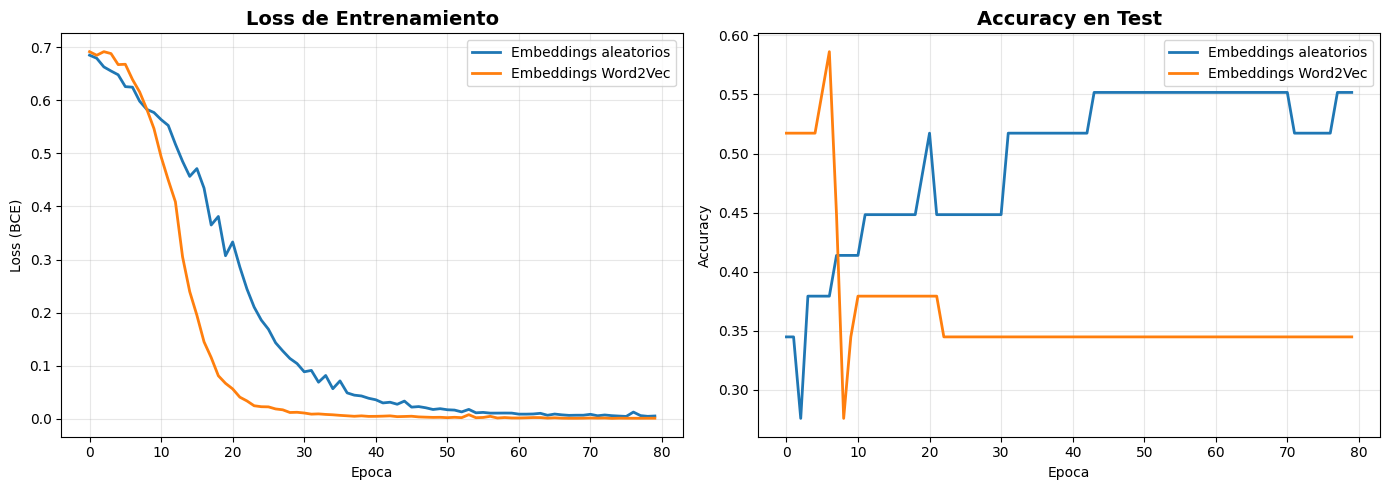


=== Comparacion con TF-IDF (baseline Guia 09) ===

Modelo                                     Accuracy
----------------------------------------------------
TF-IDF + Regresion Logistica                 0.6897
Embedding aleatorio + Promedio + Dense       0.5517
Embedding Word2Vec + Promedio + Dense        0.3448


In [29]:
# Comparar ambas opciones graficamente
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss de entrenamiento
axes[0].plot(historial_aleatorio['train_loss'], label='Embeddings aleatorios', linewidth=2)
axes[0].plot(historial_pretrained['train_loss'], label='Embeddings Word2Vec', linewidth=2)
axes[0].set_title('Loss de Entrenamiento', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss (BCE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy en test
axes[1].plot(historial_aleatorio['test_acc'], label='Embeddings aleatorios', linewidth=2)
axes[1].plot(historial_pretrained['test_acc'], label='Embeddings Word2Vec', linewidth=2)
axes[1].set_title('Accuracy en Test', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparar con TF-IDF (baseline de la Guia 09)
print("\n=== Comparacion con TF-IDF (baseline Guia 09) ===")
from sklearn.linear_model import LogisticRegression

# TF-IDF + Regresion Logistica
tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(df['texto'])
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf, df['sentimiento'].values, test_size=0.2, random_state=SEED,
    stratify=df['sentimiento'].values
)

clf_tfidf = LogisticRegression(max_iter=1000, random_state=SEED)
clf_tfidf.fit(X_train_tfidf, y_train_tfidf)
acc_tfidf = clf_tfidf.score(X_test_tfidf, y_test_tfidf)

print(f"\n{'Modelo':<40s} {'Accuracy':>10s}")
print("-" * 52)
print(f"{'TF-IDF + Regresion Logistica':<40s} {acc_tfidf:>10.4f}")
print(f"{'Embedding aleatorio + Promedio + Dense':<40s} {historial_aleatorio['test_acc'][-1]:>10.4f}")
print(f"{'Embedding Word2Vec + Promedio + Dense':<40s} {historial_pretrained['test_acc'][-1]:>10.4f}")

### ✍️ Pregunta Experimento 7

**Los embeddings pre-entrenados de Word2Vec mejoraron la clasificacion respecto a los embeddings aleatorios? Y respecto a TF-IDF? Explica por que los embeddings (incluso aleatorios) pueden ser mejores que TF-IDF para clasificacion de sentimiento. Que ventaja tienen las representaciones densas?**

****
**RESPUESTA EXPERIMENTO 7**

LOS EMBEDDINGS PREENTRENADOS DE WORD2VEC MEJORARON LA CLASIFICACION RESPECTO A LOS ALEATORIOS: PARA WORD2VEC VS ALEATORIOS LA RESPUESTA ES NO PORQUE DE HECHO EMPEORO BAJO EL ACCURACY PORQUE LA COBERTURA DEL CORPUS FUE MUY BAJA Y APENAS ALCANZO A RELLENAR LOS VALORES ALEATORIOS QUE GENERARON RUIDO. Y RESPECTO A TF-IDF ES EVIDENTE QUE NINGUNO DE LOS DOS MODELOS DE REDES NEURONALES LOGRO SUPERAR EL BASELINE TF-IDF + REGRESIÓN LOGISTICA PUES ESTA FUE LA DEL MAYOR ACCURACY Y TAMBIEN ES LA MEJOR OPCION

EXPLICACION DE POR QUE LOS EMBEDDINGS INCLUSO ALEATORIOS PUEDEN SER MEJORES QUE TF-IDF EN GENERAL: HAY DOS BUENAS RAZONES A TENER EN CUENTA LA PRIMERA ES QUE CAPTURAN LA SEMANATICA Y LAS TRATA COMO DIMENSIONES SEPARADAS Y NO DETECTA QUE SIGNIFICAN LO MISMO Y LA SEGUNDA ES QUE COMO GENERALIZO EL MODELO APRENDIO LAS PALABRAS QUE ASOCIAN A POSITIVO Y EL TF-IDF NECESITA VER LA MISMA PALABRA EN ENTRENAMIENTO

VENTAJAS: ASPECTO, DIMENSIONALIDAD, DENSIDAD, SINONIMOS, GENERALIZACION Y CAPTURA DE CONTEXTO

---

### Experimento 8: Embeddings + LSTM para Clasificacion

Ahora combinamos embeddings con una **LSTM** (Long Short-Term Memory) que aprendimos en la Guia 07. A diferencia del promedio de embeddings, la LSTM **captura el orden** de las palabras.

In [30]:
# Modelo con Embedding + LSTM + Clasificacion
class EmbeddingLSTMClassifier(nn.Module):
    """
    Clasificador de sentimiento usando Embedding + LSTM.
    Arquitectura: Embedding -> LSTM -> Dense -> Salida
    Captura el ORDEN de las palabras en la secuencia.
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim=64,
                 num_layers=1, pretrained_weights=None):
        super(EmbeddingLSTMClassifier, self).__init__()

        # Capa de Embedding
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        if pretrained_weights is not None:
            self.embedding.weight.data.copy_(pretrained_weights)
            print("  Embeddings LSTM inicializados con pesos pre-entrenados")

        # LSTM
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.2 if num_layers > 1 else 0
        )

        # Capa de clasificacion (bidireccional = hidden_dim * 2)
        self.fc1 = nn.Linear(hidden_dim * 2, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)

        # LSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)
        # lstm_out: (batch_size, seq_len, hidden_dim*2)

        # Tomar la salida del ultimo paso temporal
        # Concatenar los ultimos hidden states de ambas direcciones
        hidden_forward = hidden[-2]   # ultima capa, direccion forward
        hidden_backward = hidden[-1]  # ultima capa, direccion backward
        hidden_concat = torch.cat([hidden_forward, hidden_backward], dim=1)

        # Clasificacion
        out = self.fc1(hidden_concat)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out.squeeze()

print("Arquitectura EmbeddingLSTMClassifier definida.")
print("\nFlujo: Input -> Embedding -> BiLSTM -> Dense(32) -> ReLU -> Dropout -> Dense(1) -> Sigmoid")

Arquitectura EmbeddingLSTMClassifier definida.

Flujo: Input -> Embedding -> BiLSTM -> Dense(32) -> ReLU -> Dropout -> Dense(1) -> Sigmoid


In [31]:
# Entrenar LSTM con embeddings aleatorios
print("=" * 60)
print("LSTM con Embeddings ALEATORIOS")
print("=" * 60)

modelo_lstm_rand = EmbeddingLSTMClassifier(VOCAB_SIZE, EMBEDDING_DIM, hidden_dim=64)
historial_lstm_rand = entrenar_modelo(modelo_lstm_rand, train_loader, test_loader,
                                       epochs=80, lr=0.001)
print(f"\nAccuracy final LSTM aleatorio: {historial_lstm_rand['test_acc'][-1]:.4f}")

LSTM con Embeddings ALEATORIOS
  Epoca  10/80 | Loss: 0.5070 | Train Acc: 0.8673 | Test Acc: 0.3793
  Epoca  20/80 | Loss: 0.0086 | Train Acc: 1.0000 | Test Acc: 0.3793
  Epoca  30/80 | Loss: 0.0024 | Train Acc: 1.0000 | Test Acc: 0.3793
  Epoca  40/80 | Loss: 0.0013 | Train Acc: 1.0000 | Test Acc: 0.4483
  Epoca  50/80 | Loss: 0.0006 | Train Acc: 1.0000 | Test Acc: 0.4828
  Epoca  60/80 | Loss: 0.0004 | Train Acc: 1.0000 | Test Acc: 0.5172
  Epoca  70/80 | Loss: 0.0002 | Train Acc: 1.0000 | Test Acc: 0.5517
  Epoca  80/80 | Loss: 0.0002 | Train Acc: 1.0000 | Test Acc: 0.5172

Accuracy final LSTM aleatorio: 0.5172


In [32]:
# Entrenar LSTM con embeddings Word2Vec
print("=" * 60)
print("LSTM con Embeddings WORD2VEC")
print("=" * 60)

modelo_lstm_w2v = EmbeddingLSTMClassifier(VOCAB_SIZE, EMBEDDING_DIM, hidden_dim=64,
                                           pretrained_weights=pesos_pretrained)
historial_lstm_w2v = entrenar_modelo(modelo_lstm_w2v, train_loader, test_loader,
                                      epochs=80, lr=0.001)
print(f"\nAccuracy final LSTM Word2Vec: {historial_lstm_w2v['test_acc'][-1]:.4f}")

LSTM con Embeddings WORD2VEC
  Embeddings LSTM inicializados con pesos pre-entrenados
  Epoca  10/80 | Loss: 0.4659 | Train Acc: 0.9558 | Test Acc: 0.4483
  Epoca  20/80 | Loss: 0.0067 | Train Acc: 1.0000 | Test Acc: 0.5862
  Epoca  30/80 | Loss: 0.0027 | Train Acc: 1.0000 | Test Acc: 0.5517
  Epoca  40/80 | Loss: 0.0011 | Train Acc: 1.0000 | Test Acc: 0.5862
  Epoca  50/80 | Loss: 0.0025 | Train Acc: 1.0000 | Test Acc: 0.5862
  Epoca  60/80 | Loss: 0.0009 | Train Acc: 1.0000 | Test Acc: 0.5862
  Epoca  70/80 | Loss: 0.0006 | Train Acc: 1.0000 | Test Acc: 0.6207
  Epoca  80/80 | Loss: 0.0002 | Train Acc: 1.0000 | Test Acc: 0.6207

Accuracy final LSTM Word2Vec: 0.6207


COMPARACION FINAL DE TODOS LOS MODELOS

Modelo                                       Accuracy
------------------------------------------------------
TF-IDF + Regresion Logistica                   0.6897
Embedding aleatorio + Promedio                 0.5517
Embedding Word2Vec + Promedio                  0.3448
Embedding aleatorio + LSTM                     0.5172
Embedding Word2Vec + LSTM                      0.6207


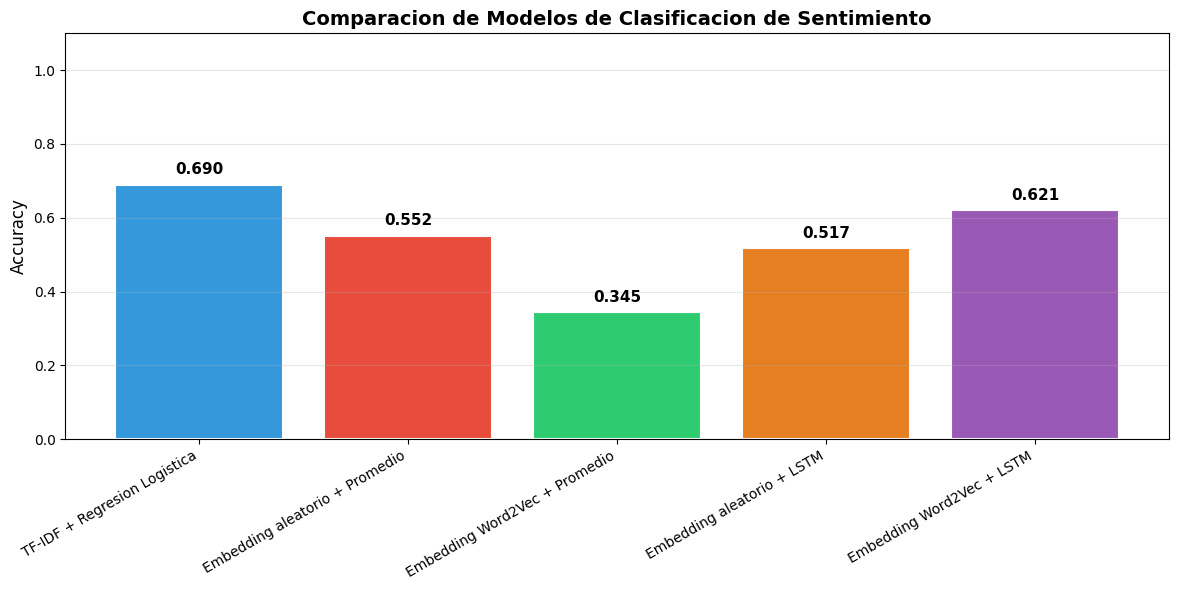

In [33]:
# Comparacion final de todos los modelos
print("=" * 60)
print("COMPARACION FINAL DE TODOS LOS MODELOS")
print("=" * 60)

resultados = {
    'TF-IDF + Regresion Logistica': acc_tfidf,
    'Embedding aleatorio + Promedio': historial_aleatorio['test_acc'][-1],
    'Embedding Word2Vec + Promedio': historial_pretrained['test_acc'][-1],
    'Embedding aleatorio + LSTM': historial_lstm_rand['test_acc'][-1],
    'Embedding Word2Vec + LSTM': historial_lstm_w2v['test_acc'][-1],
}

print(f"\n{'Modelo':<42s} {'Accuracy':>10s}")
print("-" * 54)
for modelo_nombre, acc in resultados.items():
    print(f"{modelo_nombre:<42s} {acc:>10.4f}")

# Grafico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 6))
nombres = list(resultados.keys())
accuracies = list(resultados.values())
colores_barras = ['#3498db', '#e74c3c', '#2ecc71', '#e67e22', '#9b59b6']

barras = ax.bar(range(len(nombres)), accuracies, color=colores_barras, edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels(nombres, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparacion de Modelos de Clasificacion de Sentimiento', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Agregar valores sobre las barras
for barra, acc in zip(barras, accuracies):
    ax.text(barra.get_x() + barra.get_width()/2., barra.get_height() + 0.02,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

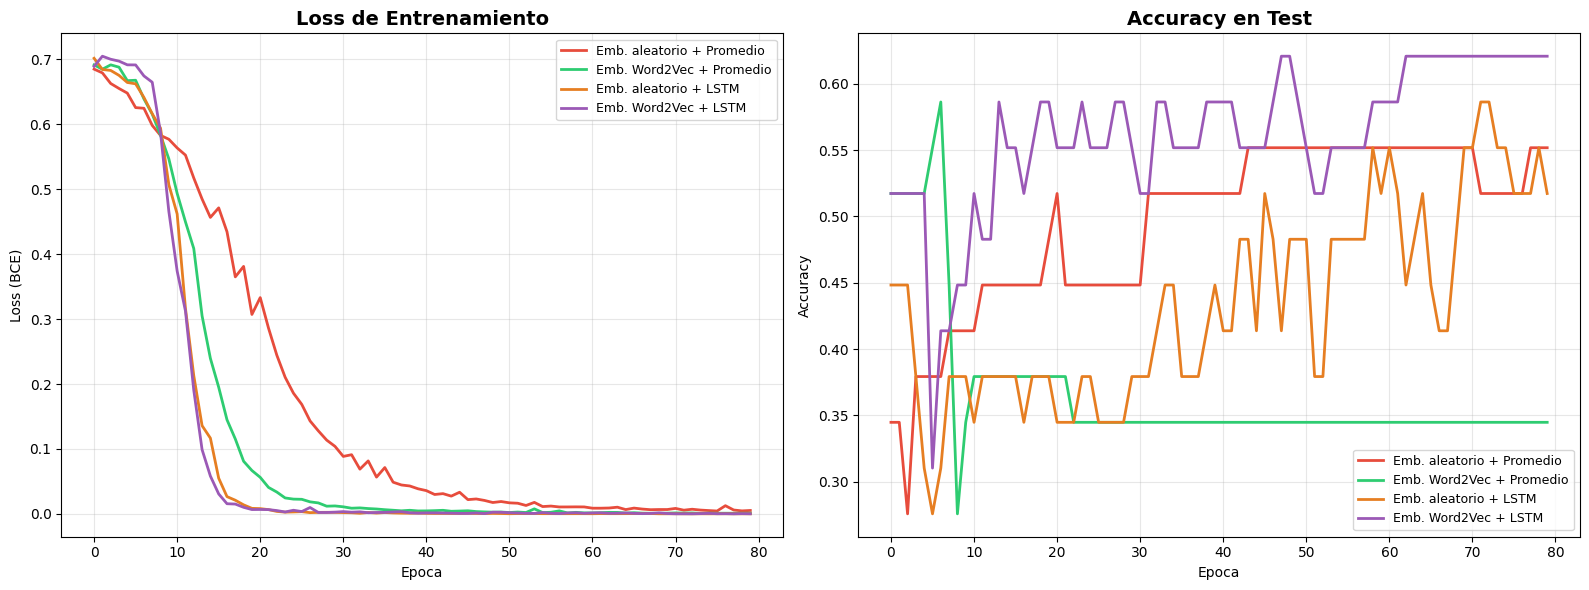

In [34]:
# Visualizar curvas de aprendizaje de todos los modelos de embeddings
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

modelos_hist = {
    'Emb. aleatorio + Promedio': historial_aleatorio,
    'Emb. Word2Vec + Promedio': historial_pretrained,
    'Emb. aleatorio + LSTM': historial_lstm_rand,
    'Emb. Word2Vec + LSTM': historial_lstm_w2v,
}

colores_lineas = ['#e74c3c', '#2ecc71', '#e67e22', '#9b59b6']

for (nombre, hist), color in zip(modelos_hist.items(), colores_lineas):
    axes[0].plot(hist['train_loss'], label=nombre, color=color, linewidth=2)
    axes[1].plot(hist['test_acc'], label=nombre, color=color, linewidth=2)

axes[0].set_title('Loss de Entrenamiento', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss (BCE)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Accuracy en Test', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### ✍️ Pregunta Experimento 8

**La LSTM mejoro respecto al promedio de embeddings? Por que tiene sentido que capturar el orden de las palabras mejore la clasificacion de sentimiento? Da un ejemplo concreto donde el orden importa (por ejemplo, "no es bueno" vs "es bueno no").**

****
**RESPUESTA EXPERIMENTO 8**

LA LSTM MEJORO RESPECTO AL PROMEDIO DE EMBEDDINGS: LA RESPUESTA ES SI PARA EL CASO DE WORD2VEC LA LSTM + WORD2VEC TUVO UNA MEJORA QUE LO ACERCO AL ALCANCE DEL BASELINE DE TF-IDF

POR QUE TIENE SENTIDO QUE CAPTURAR EL ORDEN DE LAS PALABRAS MEJORE LA CLASIFICACION DE SENTIMIENTO: PORQUE EL SIGNIFICADO DE UNA FRASE NO SOLO DEPENDE DE LAS PALABRAS QUE COMPONEN SINO TAMBIEN DE COMO SE ORGANIZAN. EL ORDEN DETERMINA LAS RELACIONES, NEGACIONES, CONTRASTES, E INTENSIFICACIONES.

EN LA FRASE EL PRODUCTO ES BUENO CUANDO ES SIN ORDEN DETECTARA BUENO COMO POSITIVO Y LSTM CON ORDEN DETECTARA BUENO COMO POSITIVO

EN LA FRASE EL PRODUCTO NO ES BUENO CUANDO ES SIN ORDEN ESTE TAMBIEN DETECTARA BUENO COMO POSITIVO LO QUE ES UN ERROR Y LSTM CON ORDEN DETECTA NO ANTES DE BUENO Y LO TRATA COMO NEGATIVO

---

## 5. Sintesis y Reflexion

Has recorrido un largo camino desde las representaciones dispersas (BoW/TF-IDF) hasta los embeddings densos con Word2Vec y su uso en redes neuronales. Es momento de consolidar lo aprendido.

### ✍️ Pregunta de Sintesis 1

**Completa la siguiente tabla comparativa:**

| Caracteristica | BoW | TF-IDF | Word2Vec Embeddings | LSTM + Embeddings |
|---|---|---|---|---|
| Tipo de representacion | Dispersa | Dispersa | DENSA | DENSA |
| Captura semantica? | No | No | SI | SI |
| Captura orden? | No | No | NO ESTATICO | SI SECUENCIAL |
| Dimensionalidad | Alta (V) | Alta (V) | BAJA 50-300 | BAJA 50-300 |
| Generaliza a sinonimos? | No | No | SI | SI |
| Necesita entrenamiento? | No | No | SI | SI |
| Contextual? | No | No | NO ESTATICO | SI POR SECUENCIA |



### ✍️ Pregunta de Sintesis 2

**Cual es la limitacion principal de Word2Vec que aun no hemos resuelto?**

Pista: Los embeddings de Word2Vec son **ESTATICOS**. La misma palabra siempre tiene el mismo vector sin importar el contexto. Piensa en la palabra "banco": tiene significados diferentes en "fui al banco a sacar dinero" y "me sente en el banco del parque", pero Word2Vec le asigna el MISMO vector.
****
**LA LIMITACION MAS NOTORIA ES LA DE WORD2VEC QUE ES ESTATICO
WORD2VEC LE ASIGNA EL MISMO VECTOR A UNA PALABRA SIN TENER EN CUENTA EL CONTEXTO EN EL QUE ESTA APARECE.

EJEMPLO 1 LA PALABRA BANCO: EN LA FRASE FUI AL BANCO A SACAR DINERO DEBE ENTENDERSE COMO INSTITUCION FINANCIERA Y EN LA FRASE ME SENTE EN EL BANCO DEL PARQUE DEBE ENTENDERSE COMO ASIENTO PARA SENTARSE. PERO WORD2VEC POR SER EL MISMO VECTOR PARA AMBAS FRASES CONFUNDE LOS SIGNIFICADOS.

EJEMPLO 2 LA PALABRA CAPA: EN LA FRASE EL SUPERHEROE USA CAPA ROJA DEBE ENTENDERSE COMO PRENDA DE VESTIR Y EN LA FRASE APLICO LA SEGUNDA CAPA DE PINTURA SOBRE LA PARED DEBE ENTENDERSE COMO RECUBRIMIENTO DE PINTURA. PERO WORD2VEC POR SER EL MISMO VECTOR PARA AMBAS FRASES CONFUNDE LOS SIGNIFICADOS.

EJEMPLO 3 LA PALABRA RATON: EN LA FRASE EL RATOS DE LA PC NO ME FUNCIONA DEBE ENTENDER COMO DISPOSITIVO Y EN LA FRASE UN RATON ENTRO A LA COCINA DEBE ENTENDER COMO ANIMAL ROEDOR. PERO WORD2VEC POR SER EL MISMO VECTOR PARA AMBAS FRASES CONFUNDE LOS SIGNIFICADOS.
**

### ✍️ Pregunta de Sintesis 3

**En la siguiente guia veremos Transformers y BERT. Basandote en las limitaciones que identificaste, que problema crees que resuelven los Transformers? Como crees que generan embeddings "contextuales"?**

*Escribe aqui tu respuesta con tu hipotesis...*

****
**QUE PROBLEMA CREES QUE RESUELVEN LOS TRANSFORMERS: PUES SI LOS EMBEDINGS TIENEN UN PROBLEMA CON RIGIDEZ POR QUE SIEMPRE ESTAN ESTATICOS A UN MISMO VECTOR EN WORD2VEC DONDE NO TIENE EN CUENTA EL SIGNIFICADO Y TIENEN DIFICULTADES PARA PROCESAR LOS TEXTOS LARGOS. CREO QUE LOS TRANSFORMES PODRAN ENTENDER PALABRA POR PALABRA Y MANTENER UN CONTEXTO POR MEMORIA A MAS LARGO PLAZO Y SERAN MAS EFICIENTES**

**COMO CREES QUE GENERAN EMBEDDINGS CONTEXTUALES: CREO QUE LOS TRANFORMES YA NO ESTAN SESGADOS A BUSQUEDAS FIJAS Y PUEDEN MOVERSE DE FORMA DINAMICA LEYENDO Y ENTENDIENDO MAS CONTEXTO Y SIGNIFICADO CONECTANDO TODAS LAS PALABRAS QUE TIENE A LA MANO PARA EVALUAR**


---

## 6. Reto Extra (Opcional)

### Entrenar Word2Vec en un corpus literario en espanol

Descarga un libro en espanol de [Project Gutenberg](https://www.gutenberg.org/) y entrena Word2Vec para explorar las relaciones semanticas del vocabulario literario.

In [35]:
# === RETO EXTRA: Word2Vec en corpus literario ===
# Descargamos "Don Quijote de la Mancha" de Project Gutenberg

import urllib.request

print("Descargando 'Don Quijote de la Mancha' de Project Gutenberg...")
url = "https://www.gutenberg.org/cache/epub/2000/pg2000.txt"

try:
    response = urllib.request.urlopen(url)
    texto_quijote = response.read().decode('utf-8')
    print(f"Texto descargado: {len(texto_quijote)} caracteres")
    print(f"Primeros 500 caracteres:\n{texto_quijote[1000:1500]}")
except Exception as e:
    print(f"Error al descargar: {e}")
    print("Puedes intentar descargar manualmente desde https://www.gutenberg.org/")
    texto_quijote = None

Descargando 'Don Quijote de la Mancha' de Project Gutenberg...
Texto descargado: 2168117 caracteres
Primeros 500 caracteres:





El ingenioso hidalgo don Quijote de la Mancha


  
Tasa

  
Testimonio de las erratas

  
El Rey

  
Al Duque de Béjar

  
Prólogo

  
Al libro de don Quijote de la Mancha



Que trata de la condición y ejercicio del famoso
hidalgo don Quijote de la Mancha

Que trata de la primera salida que de su tierra hizo
el ingenioso don Quijote

Donde se cuenta la graciosa manera que tuvo don
Quijote en armarse caballero

De lo que le sucedió a nuestro caballero cu


In [36]:
# Preprocesar y entrenar Word2Vec en el Quijote
if texto_quijote is not None:
    # Dividir en oraciones (aproximado: por puntos y saltos de linea)
    oraciones_quijote = re.split(r'[.!?\n]+', texto_quijote)
    oraciones_quijote = [o.strip() for o in oraciones_quijote if len(o.strip()) > 20]

    # Tokenizar
    corpus_quijote = []
    for oracion in oraciones_quijote:
        tokens = oracion.lower().split()
        tokens = [re.sub(r'[^a-zaeioun]', '', t) for t in tokens]
        tokens = [t for t in tokens if len(t) > 2]
        if len(tokens) > 3:
            corpus_quijote.append(tokens)

    print(f"Oraciones procesadas: {len(corpus_quijote)}")
    print(f"Ejemplo: {corpus_quijote[10]}")

    # Entrenar Word2Vec
    print("\nEntrenando Word2Vec en el Quijote...")
    modelo_quijote = Word2Vec(
        sentences=corpus_quijote,
        vector_size=150,
        window=5,
        min_count=5,
        workers=4,
        epochs=50,
        sg=1,
        seed=SEED
    )

    print(f"Modelo entrenado! Vocabulario: {len(modelo_quijote.wv)} palabras")

    # Explorar relaciones semanticas
    print("\n=== Explorando el vocabulario del Quijote ===")
    palabras_quijote = ['sancho', 'caballero', 'dulcinea', 'batalla', 'amor', 'espada']
    for palabra in palabras_quijote:
        if palabra in modelo_quijote.wv:
            similares = modelo_quijote.wv.most_similar(palabra, topn=5)
            print(f"\nSimilares a '{palabra}':")
            for p, s in similares:
                print(f"  {p:20s} -> {s:.4f}")
else:
    print("No se pudo descargar el texto. Intenta con otra URL o descargalo manualmente.")

Oraciones procesadas: 30546
Ejemplo: ['most', 'recently', 'updated', 'january']

Entrenando Word2Vec en el Quijote...
Modelo entrenado! Vocabulario: 5076 palabras

=== Explorando el vocabulario del Quijote ===

Similares a 'sancho':
  quijote              -> 0.6484
  don                  -> 0.5936
  panza                -> 0.5656
  dijo                 -> 0.5154
  que                  -> 0.5114

Similares a 'caballero':
  andante              -> 0.6139
  galn                 -> 0.4465
  tirante              -> 0.4284
  sabed                -> 0.4160
  leal                 -> 0.4008

Similares a 'dulcinea':
  toboso               -> 0.7293
  aldonza              -> 0.4951
  afirmar              -> 0.4778
  desencantada         -> 0.4743
  seora                -> 0.4532

Similares a 'batalla':
  singular             -> 0.4826
  descomunal           -> 0.4283
  ofrecieron           -> 0.3823
  cierra               -> 0.3819
  sendas               -> 0.3789

Similares a 'amor':
  promete  

Aplicando t-SNE a los embeddings del Quijote...


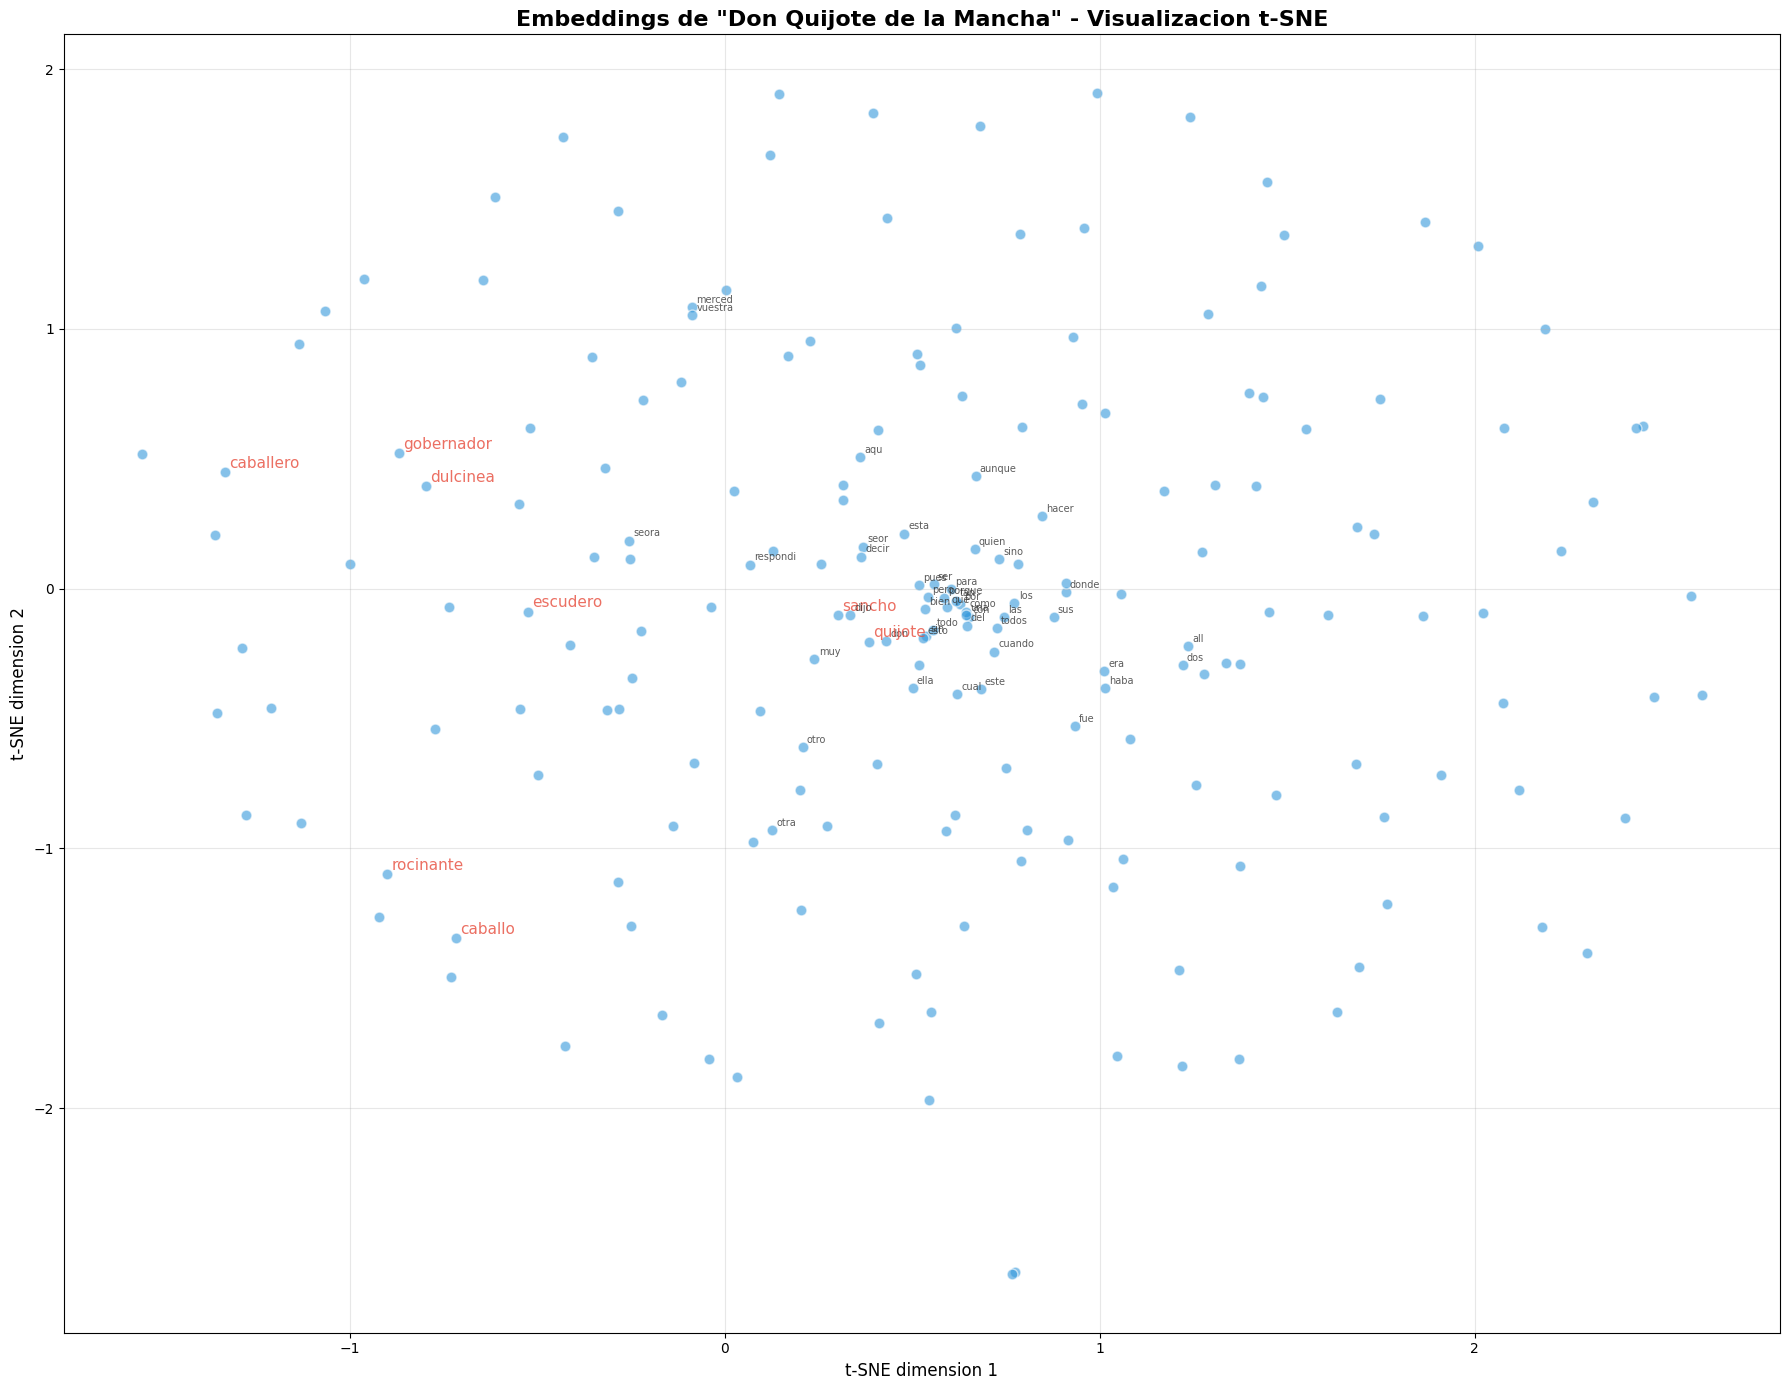


>>> Observa como el vocabulario literario del Quijote forma clusters
    tematicos: personajes, acciones de batalla, sentimientos, etc.


In [37]:
# Visualizar embeddings del Quijote con t-SNE
if texto_quijote is not None and 'modelo_quijote' in dir():
    # Tomar las 200 palabras mas frecuentes
    palabras_q = list(modelo_quijote.wv.key_to_index.keys())[:200]
    vectores_q = np.array([modelo_quijote.wv[p] for p in palabras_q])

    # t-SNE
    print("Aplicando t-SNE a los embeddings del Quijote...")
    tsne_q = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
    vectores_2d_q = tsne_q.fit_transform(vectores_q)

    # Graficar
    plt.figure(figsize=(18, 14))
    plt.scatter(vectores_2d_q[:, 0], vectores_2d_q[:, 1],
                c='#3498db', alpha=0.6, s=60, edgecolors='white')

    # Etiquetar palabras interesantes
    palabras_destacar = ['sancho', 'quijote', 'dulcinea', 'caballero', 'batalla',
                         'amor', 'espada', 'escudero', 'gigante', 'aventura',
                         'principe', 'rey', 'senor', 'caballo', 'rocinante',
                         'castillo', 'encantamiento', 'gobernador', 'ínsula']

    for i, palabra in enumerate(palabras_q):
        if palabra in palabras_destacar or i < 50:
            color_texto = '#e74c3c' if palabra in palabras_destacar else '#333333'
            tamano = 11 if palabra in palabras_destacar else 7
            plt.annotate(palabra, (vectores_2d_q[i, 0], vectores_2d_q[i, 1]),
                        fontsize=tamano, alpha=0.8, color=color_texto,
                        xytext=(3, 3), textcoords='offset points')

    plt.title('Embeddings de "Don Quijote de la Mancha" - Visualizacion t-SNE',
              fontsize=16, fontweight='bold')
    plt.xlabel('t-SNE dimension 1', fontsize=12)
    plt.ylabel('t-SNE dimension 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n>>> Observa como el vocabulario literario del Quijote forma clusters")
    print("    tematicos: personajes, acciones de batalla, sentimientos, etc.")

---

## 7. Referencias

1. **Mikolov, T., Chen, K., Corrado, G., & Dean, J.** (2013). *Efficient Estimation of Word Representations in Vector Space*. arXiv:1301.3781. [https://arxiv.org/abs/1301.3781](https://arxiv.org/abs/1301.3781)

2. **Mikolov, T., Sutskever, I., Chen, K., Corrado, G., & Dean, J.** (2013). *Distributed Representations of Words and Phrases and their Compositionality*. NeurIPS 2013. [https://arxiv.org/abs/1310.4546](https://arxiv.org/abs/1310.4546)

3. **Bojanowski, P., Grave, E., Joulin, A., & Mikolov, T.** (2017). *Enriching Word Vectors with Subword Information*. Transactions of the ACL. [https://arxiv.org/abs/1607.04606](https://arxiv.org/abs/1607.04606)

4. **Pennington, J., Socher, R., & Manning, C.** (2014). *GloVe: Global Vectors for Word Representation*. EMNLP 2014. [https://nlp.stanford.edu/projects/glove/](https://nlp.stanford.edu/projects/glove/)

5. **Gensim Documentation**. Word2Vec Model. [https://radimrehurek.com/gensim/models/word2vec.html](https://radimrehurek.com/gensim/models/word2vec.html)

6. **fastText**. Library for efficient text classification and representation learning. [https://fasttext.cc/](https://fasttext.cc/)

7. **PyTorch Documentation**. nn.Embedding. [https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html)

8. **van der Maaten, L., & Hinton, G.** (2008). *Visualizing Data using t-SNE*. JMLR. [https://www.jmlr.org/papers/v9/vandermaaten08a.html](https://www.jmlr.org/papers/v9/vandermaaten08a.html)

---

**Proxima guia:** Guia 11 - Transformers y Mecanismo de Atencion. Veremos como los Transformers resuelven la limitacion de los embeddings estaticos con representaciones **contextuales**.

---

*Guia 10 de 14 | Electiva II - Deep Learning | Tecnologico de Antioquia | 2026-1*